<a href="https://colab.research.google.com/github/prapakronmu/Data-Warehouse-and-Big-Data-Analytic_2/blob/main/673020045_9_SC663402_Pandas_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-thai-tlwg is already the newest version (1:0.7.3-1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!


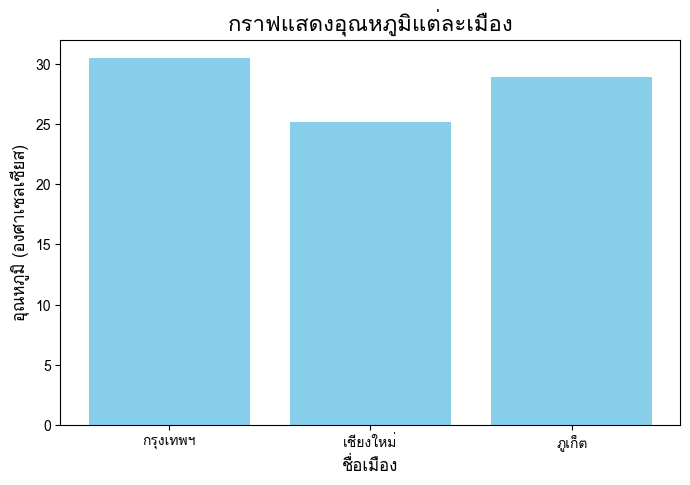

In [ ]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [ ]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [ ]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


In [ ]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


In [ ]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


In [ ]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


In [ ]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


In [ ]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


### สรุปการเปรียบเทียบคำสั่งในข้อ 1

1. **เซลล์ 1.1 (การดึงข้อมูลใน Series)**
   - `s["a"]` และ `s.iloc[0]`: คืนค่าเป็น **Scalar Value** (ชนิด `int64`) โดย `s["a"]` อ้างอิงตาม Label ส่วน `s.iloc[0]` อ้างอิงตาม Positional Index
   - `s[["a", "c"]]`: คืนค่าเป็น **Series** ใหม่ขนาด 2 รายการ
   - *ทางปฏิบัติ:* เลือกใช้ Scalar เมื่อต้องการค่าเดี่ยวไปคำนวณต่อ และใช้ List ของ Label เมื่อต้องการสร้าง Sub-series

2. **เซลล์ 1.2 (Single Bracket vs Double Bracket)**
   - `df["city"]`: คืนค่าเป็น **Series 1 มิติ** รูปร่าง `(2075,)`
   - `df[["city"]]`: คืนค่าเป็น **DataFrame 2 มิติ** รูปร่าง `(2075, 1)`
   - *ทางปฏิบัติ:* ใช้ Single Bracket เมื่อต้องการส่งเข้าฟังก์ชันรับ Series (เช่น `.str`) และใช้ Double Bracket เมื่อต้องการรักษาโครงสร้าง DataFrame หรือเลือกหลายคอลัมน์

3. **เซลล์ 1.3 (loc vs iloc Slicing)**
   - `df.loc[0:3]`: นับตาม Label Index **รวมขอบขวา** (ได้ 4 แถว: Index 0, 1, 2, 3)
   - `df.iloc[0:3]`: นับตาม Position **ไม่รวมขอบขวา** (ได้ 3 แถว: ตำแหน่ง 0, 1, 2)
   - *ทางปฏิบัติ:* ต้องระวังเรื่องขอบขวาในการ Slice ให้เหมาะกับความต้องการใช้งาน

4. **เซลล์ 1.4 (count vs size)**
   - `groupby().count()`: นับเฉพาะจำนวนข้อมูลที่ **ไม่เป็นค่าว่าง (non-NaN)** ในคอลัมน์นั้น
   - `groupby().size()`: นับ **จำนวนแถวทั้งหมด (Row Count)** ในกลุ่มโดยไม่สนใจว่าจะมีค่าว่างหรือไม่
   - *ทางปฏิบัติ:* ใช้ `.count()` เมื่อต้องการทราบความสมบูรณ์ของคอลัมน์ และใช้ `.size()` เมื่อต้องการนับจำนวนธุรกรรม/รายการทั้งหมด

5. **เซลล์ 1.5 (groupby Series vs DataFrame Output)**
   - `groupby("city")["temperature_c"].mean()`: คืนผลลัพธ์เป็น **Series**
   - `groupby("city")[["temperature_c"]].mean()`: คืนผลลัพธ์เป็น **DataFrame**
   - *ทางปฏิบัติ:* ขึ้นอยู่กับโครงสร้าง Output ที่ต้องการนำไปเชื่อมโยงหรือประมวลผลในขั้นตอนถัดไป

6. **เซลล์ 1.6 (Series Index Alignment vs NumPy Array Addition)**
   - `a + b`: ดำเนินการแบบ **Index Alignment** โดยจับคู่ข้อมูลตาม Label (`x`, `y`, `z`) ทำให้บวกค่าตรงกันอย่างถูกต้อง
   - `a.to_numpy() + b.to_numpy()`: ดำเนินการแบบ **Positional Addition** โดยบวกตามลำดับอาเรย์ ทำให้บวกผิดคู่เนื่องจาก Index ไม่ได้เรียงตรงกัน
   - *ทางปฏิบัติ:* ควรคำนวณผ่าน Pandas Series โดยตรงเพื่อป้องกันข้อผิดพลาดในการจับคู่ข้อมูล

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [ ]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [ ]:
# คำตอบข้อ 2.1
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain = rain_by_city.nlargest(3)

# 2. สัดส่วนปริมาณฝนเทียบกับฝนรวมทั้งหมด (%)
rain_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)

# 3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย
above_avg_count = (rain_by_city > rain_by_city.mean()).sum()

print("1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก:")
print(top3_rain)
print("\n2. สัดส่วนปริมาณฝนของแต่ละเมือง (%):")
print(rain_pct.head(5))
print(f"\n3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: {above_avg_count} เมือง")

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก:
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

2. สัดส่วนปริมาณฝนของแต่ละเมือง (%):
city
Auckland        4.22
Bangkok         8.21
Beijing         3.00
Berlin          3.21
Buenos Aires    3.65
Name: rainfall_mm, dtype: float64

3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ย: 8 เมือง


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [ ]:
# คำตอบข้อ 2.2
city_profile = df.groupby("city", as_index=False).agg(
    country=("country", "first"),
    region=("region", "first"),
    n_records=("date", "count"),
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
)

print("โครงสร้างตาราง city_profile:")
print(city_profile.head())


โครงสร้างตาราง city_profile:
           city      country         region  n_records   avg_temp  total_rain
0      Auckland  New Zealand        Oceania         90  17.804444       351.9
1       Bangkok     Thailand           Asia         91  32.453846       685.6
2       Beijing        China           Asia         90  15.598876       250.1
3        Berlin      Germany         Europe         90  12.383146       268.4
4  Buenos Aires    Argentina  South America         90  19.171910       305.1


---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [ ]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [ ]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [ ]:
# คำตอบข้อ 3.1
df_3_1 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city"
)

print(df_3_1.dtypes)
print("-" * 50)
df_3_1.info()

date             datetime64[ns]
region                 category
temperature_c           float64
humidity_pct            float64
rainfall_mm             float64
dtype: object
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [ ]:
# คำตอบข้อ 3.2
mem_orig = df.memory_usage(deep=True).sum()
mem_opt = df_3_1.memory_usage(deep=True).sum()
pct_reduced = ((mem_orig - mem_opt) / mem_orig * 100).round(2)

print(f"หน่วยความจำตารางเดิม: {mem_orig / 1024:.2f} KB")
print(f"หน่วยความจำตารางใหม่: {mem_opt / 1024:.2f} KB")
print(f"ปริมาณหน่วยความจำที่ลดลง: {pct_reduced}%")

หน่วยความจำตารางเดิม: 558.25 KB
หน่วยความจำตารางใหม่: 71.21 KB
ปริมาณหน่วยความจำที่ลดลง: 87.24%


คอลัมน์ที่มีผลต่อการลดลงของหน่วยความจำมากที่สุดคือ city และ region เนื่องจากข้อมูลเดิมถูกจัดเก็บเป็น String/Object ซึ่งใช้พื้นที่มาก การแปลงเป็นชนิด category ทำให้ Pandas เปลี่ยนไปเก็บเป็นรหัสตัวเลข (Integer Codes) และเก็บตารางอ้างอิง String เพียงครั้งเดียว ประกอบกับการกำหนด usecols เพื่อเลือกอ่านเฉพาะคอลัมน์ที่จำเป็น จึงลดขนาด Memory Footprint ลงได้อย่างมหาศาล

### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [ ]:
# คำตอบข้อ 3.3
max_temp = float("-inf")
min_temp = float("inf")
city_sum = pd.Series(dtype=float)
city_count = pd.Series(dtype=float)

for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500, na_values=[999, -999]):
    # 1. หาค่าสูงสุดและต่ำสุด
    chunk_max = chunk["temperature_c"].max()
    chunk_min = chunk["temperature_c"].min()
    if pd.notna(chunk_max) and chunk_max > max_temp:
        max_temp = chunk_max
    if pd.notna(chunk_min) and chunk_min < min_temp:
        min_temp = chunk_min

    # 2. สะสม sum และ count สำหรับคำนวณ mean รายเมือง
    grouped = chunk.groupby("city")["temperature_c"]
    city_sum = city_sum.add(grouped.sum(), fill_value=0)
    city_count = city_count.add(grouped.count(), fill_value=0)

city_avg_temp = city_sum / city_count

print(f"1. อุณหภูมิสูงสุด: {max_temp} °C, อุณหภูมิต่ำสุด: {min_temp} °C")
print("\n2. อุณหภูมิเฉลี่ยรายเมือง (คำนวณจาก chunk):")
print(city_avg_temp.head())

1. อุณหภูมิสูงสุด: 39.2 °C, อุณหภูมิต่ำสุด: -88.0 °C

2. อุณหภูมิเฉลี่ยรายเมือง (คำนวณจาก chunk):
city
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
dtype: float64


คำอธิบาย: การนำค่าเฉลี่ยของแต่ละก้อน (Chunk Means) มาหาค่าเฉลี่ยซ้ำอีกครั้งเป็นสิ่ง ไม่ถูกต้อง เนื่องจากแต่ละ Chunk อาจมีจำนวนข้อมูลที่ไม่เท่ากัน (Unweighted Average) ทำให้ก้อนที่มีข้อมูลน้อยมีน้ำหนักเท่ากับก้อนที่มีข้อมูลมาก ค่าเฉลี่ยรวมจึงคลาดเคลื่อน
วิธีที่ถูกต้อง: ต้องสะสมผลรวมข้อมูล (sum) และจำนวนข้อมูลที่ไม่เป็นค่าว่าง (count) ของแต่ละ Chunk แยกกันไว้ แล้วนำ sum_total / count_total ในขั้นตอนสุดท้าย

---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2075 entries, 0 to 2074
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   record_id       2075 non-null   int64  
 1   date            2075 non-null   object 
 2   city            2075 non-null   object 
 3   country         2075 non-null   object 
 4   region          2075 non-null   object 
 5   temperature_c   2055 non-null   float64
 6   humidity_pct    1993 non-null   float64
 7   rainfall_mm     2013 non-null   float64
 8   wind_speed_kmh  2034 non-null   float64
 9   pressure_hpa    2043 non-null   float64
dtypes: float64(5), int64(1), object(4)
memory usage: 162.2+ KB


In [ ]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

       record_id  temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  \
count    2075.00        2055.00       1993.00      2013.00         2034.00   
mean     1035.15          21.84         66.82         4.15           14.78   
std       598.02          38.22         13.09         3.85            5.88   
min         1.00         -88.00         21.50         0.00           -5.00   
25%       517.50          15.40         58.60         0.30           10.80   
50%      1035.00          20.00         67.10         3.50           15.00   
75%      1553.50          25.70         75.50         6.60           18.70   
max      2070.00         999.00        150.00        17.60           33.70   

       pressure_hpa  
count       2043.00  
mean        1013.13  
std            5.86  
min          993.90  
25%         1009.30  
50%         1013.10  
75%         1017.20  
max         1030.60  
        record_id        date        city   country region  temperature_c  \
count      2075.0     

In [ ]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

record_id          0
date               0
city               0
country            0
region             0
temperature_c     20
humidity_pct      82
rainfall_mm       62
wind_speed_kmh    41
pressure_hpa      32
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 229
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [ ]:
# คำตอบข้อ 4.1
summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True),
    "example_value": df.iloc[0]
}).sort_values("n_missing", ascending=False)

print(summary)

                  dtype  n_missing  pct_missing  n_unique  example_value
humidity_pct    float64         82         3.95       544           72.6
rainfall_mm     float64         62         2.99       164            6.3
wind_speed_kmh  float64         41         1.98       278           15.9
pressure_hpa    float64         32         1.54       294         1005.4
temperature_c   float64         20         0.96       331           15.7
record_id         int64          0         0.00      2070            983
date             object          0         0.00        90     2025-03-24
region           object          0         0.00         6  North America
city             object          0         0.00        23       New York
country          object          0         0.00        28            USA


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [ ]:
# คำตอบข้อ 4.2
invalid_temp = (df["temperature_c"] < -60) | (df["temperature_c"] > 60)
invalid_hum = (df["humidity_pct"] < 0) | (df["humidity_pct"] > 100)

n_invalid_temp = invalid_temp.sum()
n_invalid_hum = invalid_hum.sum()
n_invalid_any = (invalid_temp | invalid_hum).sum()

print(f"1. จำนวนแถวที่ temperature_c ผิดปกติ: {n_invalid_temp} แถว")
print(f"2. จำนวนแถวที่ humidity_pct ผิดปกติ: {n_invalid_hum} แถว")
print(f"3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: {n_invalid_any} แถว")


1. จำนวนแถวที่ temperature_c ผิดปกติ: 5 แถว
2. จำนวนแถวที่ humidity_pct ผิดปกติ: 3 แถว
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์: 8 แถว


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [ ]:
# คำตอบข้อ 4.3
# 1. แสดงค่าที่หมายถึงประเทศเดียวกันแต่ถูกนับแยก
print("ค่า country ดั้งเดิมที่ไม่ซ้ำกัน:")
print(df["country"].unique())

# 3. วิธี Normalize ที่ถูกต้อง (strip + title / map อักษรย่อเฉพาะ)
def normalize_country(s):
    cleaned = s.str.strip().str.title()
    # แก้ไขอักษรย่อเฉพาะ เช่น USA, UK ไม่ให้กลายเป็น Usa, Uk
    mapping = {"Usa": "USA", "Uk": "UK"}
    return cleaned.replace(mapping)

df_clean_country = df.copy()
df_clean_country["country"] = normalize_country(df_clean_country["country"])

print(f"\nจำนวนประเทศหลัง Normalize: {df_clean_country['country'].nunique()} ประเทศ")

ค่า country ดั้งเดิมที่ไม่ซ้ำกัน:
['USA' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'UK' 'Thailand' 'Germany' 'Brazil' 'Canada' 'GERMANY'
 'CANADA' 'SINGAPORE' 'NEW ZEALAND' 'ARGENTINA' 'JAPAN' 'KENYA']

จำนวนประเทศหลัง Normalize: 21 ประเทศ


คำอธิบาย 4.3 (ข้อ 2): การใช้ df["country"].str.title() จะแปลงอักษรตัวแรกของทุกคำเป็นตัวพิมพ์ใหญ่และอักษรที่เหลือเป็นตัวพิมพ์เล็ก ทำให้ชื่อประเทศที่เป็นอักษรย่อพิมพ์ใหญ่ทั้งหมดเสียหาย เช่น "USA" จะถูกเปลี่ยนเป็น "Usa" และ "UK" จะกลายเป็น "Uk" ซึ่งเป็นการสะกดที่ไม่ถูกต้องตามมาตรฐาน

---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [ ]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
          city        date  temperature_c
78   Cape Town  2025-02-10          999.0
161    Bangkok  2025-02-14           38.6
325     Mumbai  2025-03-31           35.6


In [ ]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(542, 8)
                    date  temperature_c
region city                            
Asia   Tokyo  2025-02-09           18.3
       Tokyo  2025-03-21           19.7
       Tokyo  2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [ ]:
# คำตอบข้อ 5.1
# 1. แถวตำแหน่งเลขคู่ 10 แถวแรก เฉพาะ 3 คอลัมน์สุดท้าย
q1 = df.iloc[0:20:2, -3:]

# 2. 5 แถวสุดท้าย เรียงจากล่างขึ้นบน
q2 = df.iloc[:-6:-1]

# 3. ค่าเดี่ยวแถวกึ่งกลางและคอลัมน์สุดท้าย
mid_idx = len(df) // 2
q3 = df.iloc[mid_idx, -1]

print("1. 10 แถวแรกตำแหน่งเลขคู่ เฉพาะ 3 คอลัมน์สุดท้าย:")
print(q1)
print("\n2. 5 แถวสุดท้าย เรียงจากล่างสุดขึ้นไป:")
print(q2)
print(f"\n3. ค่าเดี่ยวแถวกึ่งกลาง (Index {mid_idx}) คอลัมน์สุดท้าย: {q3}")

1. 10 แถวแรกตำแหน่งเลขคู่ เฉพาะ 3 คอลัมน์สุดท้าย:
    rainfall_mm  wind_speed_kmh  pressure_hpa
0           6.3            15.9        1005.4
2           1.2             8.6        1013.5
4           0.0            16.6        1015.1
6           2.7            14.6        1018.0
8           1.6             9.8        1007.7
10          0.0            15.6        1010.1
12          0.0            13.6        1015.8
14          2.2            24.6        1000.5
16          8.3             9.3        1019.4
18          8.9            23.3        1020.6

2. 5 แถวสุดท้าย เรียงจากล่างสุดขึ้นไป:
      record_id        date         city country         region  \
2074        642  2025-01-12        Paris  France         Europe   
2073       1210  2025-02-09      Toronto  Canada  North America   
2072       1738  2025-01-28      Nairobi   Kenya         Africa   
2071       1769  2025-02-28      Nairobi   Kenya         Africa   
2070       1093  2025-01-13  Mexico City  Mexico  North America   

 

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [ ]:
# คำตอบข้อ 5.2
multi = df.set_index(["region", "city"]).sort_index()

# 1. ข้อมูลภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
asia_temp = multi.loc["Asia", ["date", "temperature_c"]]

# 2. ข้อมูล Tokyo และ Bangkok พร้อมกัน
tokyo_bkk = multi.loc[(slice(None), ["Tokyo", "Bangkok"]), :]

# 3. ทุกภูมิภาค เฉพาะเมืองที่ขึ้นต้นด้วย B
b_cities = multi.loc[(slice(None), multi.index.get_level_values("city").str.startswith("B")), :]

print("1. Asia (date, temperature_c):", asia_temp.shape)
print("2. Tokyo & Bangkok:", tokyo_bkk.shape)
print("3. เมืองที่ขึ้นต้นด้วย B:", b_cities.shape)

1. Asia (date, temperature_c): (542, 2)
2. Tokyo & Bangkok: (181, 8)
3. เมืองที่ขึ้นต้นด้วย B: (361, 8)


คำอธิบาย ข้อ 5.2
คำอธิบาย: การใช้ Index หลายระดับ (MultiIndex) ใน Pandas โดยเฉพาะเมื่อเลือกข้อมูลด้วยการ Slice จำเป็นต้องจัดเรียง Index ล่วงหน้าด้วย .sort_index() เนื่องจาก Pandas อาศัยโครงสร้างแบบเรียงลำดับในการค้นหาขอบเขตข้อมูล หากไม่จัดเรียงอาจทำให้เกิดความล่าช้าอย่างมาก หรือเกิด UnsortedIndexError / KeyError ในขณะประมวลผล

### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [ ]:
# คำตอบข้อ 5.3
# รูปแบบที่ 1: ต้องการแก้ไข df จริง (แก้ Chained Indexing ด้วย .loc)
df_correct_1 = df.copy()
df_correct_1.loc[df_correct_1["city"] == "Bangkok", "temperature_c"] = 0

# รูปแบบที่ 2: ต้องการทำงานกับสำเนาแยกต่างหาก (ใช้ .copy() ชัดเจน)
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

print("แก้ไขบน DataFrame หลักเรียบร้อยแล้ว (จำนวนแถว Bangkok =", len(subset), ")")

แก้ไขบน DataFrame หลักเรียบร้อยแล้ว (จำนวนแถว Bangkok = 91 )


แนวปฏิบัติ: หลีกเลี่ยงการกำหนดค่าผ่านการเลือกข้อมูลซ้อนกัน (Chained Indexing) เช่น df[cond][col] = val เพราะจะเกิด SettingWithCopyWarning ให้ใช้ .loc[row_indexer, col_indexer] = value เมื่อต้องการแก้ไข DataFrame ต้นทาง และใช้ .copy() เสมอเมื่อต้องการแยก View ออกมาทำงานต่างหากโดยไม่กระทบข้อมูลหลัก

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [ ]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

237
1894
757
295


In [ ]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 20
15.0 17.6


In [ ]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [ ]:
# คำตอบข้อ 6.1
# 1. เอเชีย ฝน > 5 มม. ความเร็วลม > 20 กม./ชม.
cond1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]

# 2. ไม่ใช่ Bangkok, Tokyo, London ความชื้น 40-60
cond2 = df[(~df["city"].isin(["Bangkok", "Tokyo", "London"])) & (df["humidity_pct"].between(40, 60))]

# 3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
cond3 = df[df.isna().sum(axis=1) >= 2]

# 4. เมืองที่มีคำว่า New หรือ San
cond4 = df[df["city"].str.contains(r"New|San", na=False)]

print(f"จำนวนแถวตามเงื่อนไข 1: {len(cond1)}")
print(f"จำนวนแถวตามเงื่อนไข 2: {len(cond2)}")
print(f"จำนวนแถวตามเงื่อนไข 3: {len(cond3)}")
print(f"จำนวนแถวตามเงื่อนไข 4: {len(cond4)}")

จำนวนแถวตามเงื่อนไข 1: 54
จำนวนแถวตามเงื่อนไข 2: 470
จำนวนแถวตามเงื่อนไข 3: 8
จำนวนแถวตามเงื่อนไข 4: 90


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 6.2
df_6_2 = df.copy()

# คอลัมน์อุณหภูมิที่แทนค่าผิดปกติ (-60 ถึง 60) ด้วยค่าว่าง
df_6_2["temp_cleaned"] = df_6_2["temperature_c"].where(df_6_2["temperature_c"].between(-60, 60))

# คอลัมน์ปริมาณฝนจำกัดค่าสูงสุดไว้ที่ Percentile 99
p99_rain = df_6_2["rainfall_mm"].quantile(0.99)
df_6_2["rain_capped"] = df_6_2["rainfall_mm"].mask(df_6_2["rainfall_mm"] > p99_rain, p99_rain)

print(f"ค่า Percentile 99 ของปริมาณฝน: {p99_rain:.2f} mm")
print("ตัวอย่างผลลัพธ์คอลัมน์ใหม่:")
print(df_6_2[["temperature_c", "temp_cleaned", "rainfall_mm", "rain_capped"]].head())

ค่า Percentile 99 ของปริมาณฝน: 14.69 mm
ตัวอย่างผลลัพธ์คอลัมน์ใหม่:
   temperature_c  temp_cleaned  rainfall_mm  rain_capped
0           15.7          15.7          6.3          6.3
1           18.3          18.3          0.0          0.0
2           20.6          20.6          1.2          1.2
3           31.0          31.0          8.0          8.0
4           19.1          19.1          0.0          0.0


คำอธิบาย: การใช้ .where() และ .mask() เป็นการทำความสะอาดเฉพาะเซลล์ที่เป็นค่าผิดปกติ โดยยังรักษารายการแถวของวันและเมืองนั้นเอาไว้ (Data Retention) แตกต่างจากการลบแถวทิ้งด้วย dropna() ที่จะสูญเสียข้อมูลตัววัดอื่นในแถวนั้นไปด้วย ซึ่งช่วยป้องกันการลดลงของขนาดตัวอย่าง (Sample Size) และลดอคติ (Bias) ในการวิเคราะห์มิติอื่นๆ ในขั้นถัดไป

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [ ]:
# คำตอบข้อ 6.3
df_dev = df.copy()
city_avg = df_dev.groupby("city")["temperature_c"].transform("mean")
df_dev["deviation"] = (df_dev["temperature_c"] - city_avg).abs()

# หาวันที่มี deviation มากที่สุดของแต่ละเมือง
max_dev_idx = df_dev.groupby("city")["deviation"].idxmax().dropna()
result_6_3 = df_dev.loc[max_dev_idx, ["city", "date", "temperature_c", "deviation"]].sort_values("deviation", ascending=False)

print(result_6_3.head(10))

              city        date  temperature_c   deviation
712          Paris  2025-03-28          999.0  973.188764
78       Cape Town  2025-02-10          999.0  968.837079
1855     Singapore  2025-03-11          999.0  958.916667
1280  Buenos Aires  2025-01-19          -88.0  107.171910
747         London  2025-02-09           23.4    9.909091
1834      New York  2025-03-16           24.5    9.023333
34            Lima  2025-01-22           12.9    8.590000
17          Sydney  2025-03-06           11.8    8.547778
552          Lagos  2025-01-01           21.1    8.394253
855        Toronto  2025-01-07            3.5    8.113636


---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [ ]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [ ]:
# คำตอบข้อ 7.1
df_7_1 = df.assign(
    date=pd.to_datetime(df["date"]),
    year_month=lambda x: x["date"].dt.to_period("M"),
    week_of_year=lambda x: x["date"].dt.isocalendar().week,
    day_name=lambda x: x["date"].dt.day_name(),
    is_weekend=lambda x: x["date"].dt.dayofweek >= 5
)

print(df_7_1[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head())

        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True
4 2025-02-03    2025-02             6    Monday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [ ]:
# คำตอบข้อ 7.2
# 1. จำนวนวันครอบคลุม และตรวจสอบวันหาย
full_range = pd.date_range(start=df_7_1["date"].min(), end=df_7_1["date"].max())
missing_dates = full_range.difference(df_7_1["date"].unique())
print(f"1. ข้อมูลครอบคลุมทั้งหมด {len(full_range)} วัน | วันที่ไม่มีข้อมูลเลย: {len(missing_dates)} วัน")

# 2. อุณหภูมิเฉลี่ยวันหยุด vs วันธรรมดา จำแนกตามภูมิภาค
temp_weekend_comp = df_7_1.groupby(["region", "is_weekend"])["temperature_c"].mean().unstack()
temp_weekend_comp.columns = ["วันธรรมดา", "วันหยุด"]
print("\n2. อุณหภูมิเฉลี่ยจำแนกตามภูมิภาคและประเภทวัน:")
print(temp_weekend_comp.round(2))

# 3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง
monthly_rain = df_7_1.groupby(["city", "year_month"])["rainfall_mm"].sum().reset_index()
max_rain_month = monthly_rain.loc[monthly_rain.groupby("city")["rainfall_mm"].idxmax()]
print("\n3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง (ตัวอย่าง 5 เมือง):")
print(max_rain_month.head())

1. ข้อมูลครอบคลุมทั้งหมด 90 วัน | วันที่ไม่มีข้อมูลเลย: 0 วัน

2. อุณหภูมิเฉลี่ยจำแนกตามภูมิภาคและประเภทวัน:
               วันธรรมดา  วันหยุด
region                           
Africa             27.94    23.88
Asia               28.49    26.53
Europe             15.82    11.95
North America      16.72    16.84
Oceania            18.94    19.40
South America      21.70    19.84

3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง (ตัวอย่าง 5 เมือง):
            city year_month  rainfall_mm
2       Auckland    2025-03        150.0
4        Bangkok    2025-02        243.9
7        Beijing    2025-02         87.4
11        Berlin    2025-03        100.1
13  Buenos Aires    2025-02        121.2


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [ ]:
# คำตอบข้อ 7.3
bkk = df[df["city"] == "Bangkok"].copy()
bkk["date"] = pd.to_datetime(bkk["date"])
bkk = bkk.set_index("date").sort_index()

resampled_bkk = bkk.resample("7D").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum")
)

print(resampled_bkk.head())

             avg_temp  total_rain
date                             
2025-01-01  30.357143        65.7
2025-01-08  31.085714        47.6
2025-01-15  30.385714        58.7
2025-01-22  32.285714        50.0
2025-01-29  31.757143        55.4


คำอธิบาย: .resample() จัดกลุ่มข้อมูลตามช่วงเวลาที่มีความยาวคงที่อิงตามปฏิทินจริง (เช่น ราย 7 วัน 7D หรือรายสัปดาห์) ในขณะที่ groupby(df["date"].dt.month) จัดกลุ่มเชิงสัญลักษณ์ตามเลขเดือน (1-12)
กรณีที่จำเป็นต้องใช้ .resample(): เมื่อต้องการสรุปข้อมูลตาม Window เวลาถี่ที่ไม่ใช่รอบเดือนปกติ หรือเมื่อต้องการเติมช่องว่างช่วงเวลาที่ไม่มีข้อมูล (Missing Timestamps) ในชุดข้อมูลอนุกรมเวลา

---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [ ]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

20 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


In [ ]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 5
ซ้ำตามคีย์ (city, date): 5
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [ ]:
# คำตอบข้อ 8.1
# 1. คอลัมน์ที่มีค่าว่างมากที่สุด
max_miss_col = df.isna().sum().idxmax()
max_miss_pct = (df[max_miss_col].isna().mean() * 100).round(2)
print(f"1. คอลัมน์ที่มีค่าว่างมากที่สุด: {max_miss_col} ({max_miss_pct}%)")

# 2. สัดส่วนค่าว่าง temperature_c จำแนกตามเมือง
null_by_city = df.groupby("city")["temperature_c"].apply(lambda s: s.isna().mean() * 100).round(2)
print("\n2. สัดส่วนค่าว่างของ temperature_c รายเมือง (%):")
print(null_by_city.head())

# 3. ผลกระทบการใช้ dropna()
df_dropped = df.dropna()
remaining_pct = round((len(df_dropped) / len(df) * 100), 2)
most_lost_city = df.isna().any(axis=1).groupby(df["city"]).sum().idxmax()
print(f"\n3. หลัง dropna() เหลือข้อมูล: {remaining_pct}% | เมืองที่สูญเสียข้อมูลมากที่สุด: {most_lost_city}")

1. คอลัมน์ที่มีค่าว่างมากที่สุด: humidity_pct (3.95%)

2. สัดส่วนค่าว่างของ temperature_c รายเมือง (%):
city
Auckland        0.00
Bangkok         0.00
Beijing         1.11
Berlin          1.11
Buenos Aires    1.11
Name: temperature_c, dtype: float64

3. หลัง dropna() เหลือข้อมูล: 88.96% | เมืองที่สูญเสียข้อมูลมากที่สุด: Auckland


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [ ]:
# คำตอบข้อ 8.2
df_imp = df.copy()
df_imp["date"] = pd.to_datetime(df_imp["date"])

# 1. เติมด้วยค่าเฉลี่ยรวม
fill_overall = df_imp["temperature_c"].fillna(df_imp["temperature_c"].mean())

# 2. เติมด้วยค่าเฉลี่ยเมืองตนเอง
fill_city = df_imp["temperature_c"].fillna(df_imp.groupby("city")["temperature_c"].transform("mean"))

# 3. เติมด้วย Forward Fill รายเมือง
df_imp = df_imp.sort_values(["city", "date"])
fill_ffill = df_imp.groupby("city")["temperature_c"].ffill()

# เปรียบเทียบผลกระทบต่อ mean และ std รายเมือง
comp = pd.DataFrame({
    "orig_mean": df_imp.groupby("city")["temperature_c"].mean(),
    "orig_std": df_imp.groupby("city")["temperature_c"].std(),
    "city_mean": df_imp.assign(t=fill_city).groupby("city")["t"].mean(),
    "city_std": df_imp.assign(t=fill_city).groupby("city")["t"].std(),
    "overall_mean": df_imp.assign(t=fill_overall).groupby("city")["t"].mean(),
    "overall_std": df_imp.assign(t=fill_overall).groupby("city")["t"].std(),
    "ffill_mean": df_imp.assign(t=fill_ffill).groupby("city")["t"].mean(),
    "ffill_std": df_imp.assign(t=fill_ffill).groupby("city")["t"].std()
}).round(2)

print(comp.head())

              orig_mean  orig_std  city_mean  city_std  overall_mean  \
city                                                                   
Auckland          17.80      2.80      17.80      2.80         17.80   
Bangkok           32.45      2.48      32.45      2.48         32.45   
Beijing           15.60      2.87      15.60      2.86         15.67   
Berlin            12.38      2.60      12.38      2.58         12.49   
Buenos Aires      19.17     11.82      19.17     11.75         19.20   

              overall_std  ffill_mean  ffill_std  
city                                              
Auckland             2.80       17.80       2.80  
Bangkok              2.48       32.45       2.48  
Beijing              2.93       15.62       2.87  
Berlin               2.77       12.34       2.61  
Buenos Aires        11.75       19.14      11.76  


คำอธิบาย: วิธีการเติมด้วย ค่าเฉลี่ยของเมืองตนเอง หรือ Forward Fill (ค่าวันก่อนหน้า) เหมาะสมที่สุดสำหรับอนุกรมเวลาสภาพอากาศ เนื่องจากสะท้อนลักษณะภูมิอากาศเฉพาะถิ่น ในขณะที่วิธี การเติมด้วยค่าเฉลี่ย (Mean Imputation) ทั้งแบบรวมและแบบรายเมือง จะส่งผลให้ ความแปรปรวน (Variance / Standard Deviation) ของข้อมูลลดลงอย่างผิดธรรมชาติ เนื่องจากเป็นการเติมค่ากลางซ้ำๆ เข้าไปในชุดข้อมูล

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [ ]:
# คำตอบข้อ 8.3
# 1. จำนวนคีย์ (city, date) ที่ซ้ำกัน
dup_keys = df.duplicated(subset=["city", "date"]).sum()

# 2. ตรวจสอบประเภทการซ้ำ
dup_all = df.duplicated().sum()
print(f"1. มีคู่ (city, date) ซ้ำกัน {dup_keys} คู่")
print(f"2. ซ้ำทุกคอลัมน์: {dup_all} แถว | ซ้ำเฉพาะคีย์แต่ค่าต่างกัน: {dup_keys - dup_all} แถว")

# 3. ขจัดข้อมูลซ้ำและตรวจสอบจำนวนแถว
df_clean = df.drop_duplicates(subset=["city", "date"], keep="first").copy()
expected_rows = df["city"].nunique() * df["date"].nunique()
print(f"3. จำนวนแถวหลังขจัดข้อมูลซ้ำ: {len(df_clean)} แถว (ตรงตามเป้าหมาย 2070 แถว: {len(df_clean) == 2070})")

1. มีคู่ (city, date) ซ้ำกัน 5 คู่
2. ซ้ำทุกคอลัมน์: 5 แถว | ซ้ำเฉพาะคีย์แต่ค่าต่างกัน: 0 แถว
3. จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070 แถว (ตรงตามเป้าหมาย 2070 แถว: True)


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [ ]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 11)


### ตัวอย่าง

In [ ]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland     17.80       351.9      26.0      90
Bangkok      32.44       680.0      29.8      90
Beijing      15.60       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [ ]:
# คำตอบข้อ 9.1
summary_9_1 = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum()),
    pct_missing_temp=("temperature_c", lambda x: (x.isna().mean() * 100).round(2))
)

print(summary_9_1.head())

               avg_temp  median_temp   std_temp  total_rain  heavy_rain_days  \
city                                                                           
Auckland      17.804444        17.55   2.799475       351.9                6   
Bangkok       32.438889        32.50   2.490462       680.0               23   
Beijing       15.598876        15.50   2.874792       250.1                2   
Berlin        12.383146        12.30   2.595986       268.4                6   
Buenos Aires  19.171910        20.70  11.817985       305.1                9   

              pct_missing_temp  
city                            
Auckland                  0.00  
Bangkok                   0.00  
Beijing                   1.11  
Berlin                    1.11  
Buenos Aires              1.11  


### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [ ]:
# คำตอบข้อ 9.2
region_month = (
    df.groupby(["region", "month"])
    .agg(avg_temp=("temperature_c", "mean"))
    .reset_index()
)

max_row = region_month.loc[region_month["avg_temp"].idxmax()]
min_row = region_month.loc[region_month["avg_temp"].idxmin()]

print("ตารางสรุปจำแนกตามภูมิภาคและเดือน (5 แถวแรก):")
print(region_month.head())
print(f"\nคู่ (ภูมิภาค, เดือน) ที่มีอุณหภูมิเฉลี่ยสูงสุด: {max_row['region']} เดือน {int(max_row['month'])} ({max_row['avg_temp']:.2f} °C)")
print(f"คู่ (ภูมิภาค, เดือน) ที่มีอุณหภูมิเฉลี่ยต่ำสุด: {min_row['region']} เดือน {int(min_row['month'])} ({min_row['avg_temp']:.2f} °C)")

ตารางสรุปจำแนกตามภูมิภาคและเดือน (5 แถวแรก):
   region  month   avg_temp
0  Africa      1  22.641667
1  Africa      2  32.741441
2  Africa      3  25.414754
3    Asia      1  24.196774
4    Asia      2  26.762275

คู่ (ภูมิภาค, เดือน) ที่มีอุณหภูมิเฉลี่ยสูงสุด: Africa เดือน 2 (32.74 °C)
คู่ (ภูมิภาค, เดือน) ที่มีอุณหภูมิเฉลี่ยต่ำสุด: Europe เดือน 1 (10.40 °C)


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [ ]:
# คำตอบข้อ 9.3
proof = df.groupby("city").agg(
    n_days_count=("temperature_c", "count"),
    n_days_size=("temperature_c", "size")
)
proof["diff"] = proof["n_days_size"] - proof["n_days_count"]

print("หลักฐานเปรียบเทียบ count vs size (แสดงเฉพาะเมืองที่มีค่าว่าง):")
print(proof[proof["diff"] > 0])

หลักฐานเปรียบเทียบ count vs size (แสดงเฉพาะเมืองที่มีค่าว่าง):
              n_days_count  n_days_size  diff
city                                         
Beijing                 89           90     1
Berlin                  89           90     1
Buenos Aires            89           90     1
Cairo                   88           90     2
Cape Town               89           90     1
Lagos                   87           90     3
London                  88           90     2
Los Angeles             89           90     1
Moscow                  89           90     1
Nairobi                 89           90     1
Paris                   89           90     1
Sao Paulo               89           90     1
Tokyo                   88           90     2
Toronto                 88           90     2


คำอธิบาย: คอลัมน์ n_days ที่คำนวณจาก count กับ size ให้ผลลัพธ์ ต่างกัน ในเมืองที่มีข้อมูลค่าว่าง (NaN)

count() นับเฉพาะจำนวนข้อมูลที่ไม่เป็นค่าว่าง (non-null values)

size() นับจำนวนแถวทั้งหมดของกลุ่มนั้น (row count)
การรายงานคลาดเคลื่อน: หากเลือกใช้ผิด เช่น ใช้ count นับจำนวนวันทั้งหมดในตาราง จะทำให้รายงานจำนวนวันต่ำกว่าความเป็นจริงในกรณีที่มีค่าว่าง ในทางกลับกัน หากต้องการนับจำนวนวันที่มีการบันทึกค่าอุณหภูมิได้จริง การใช้ size จะรวมวันที่มีค่าว่างเข้าไปด้วย ทำให้รายงานจำนวนวันที่มีข้อมูลสูงกว่าจริง

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [ ]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


In [ ]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    2050.000
mean        0.000
std         0.995
min        -9.069
25%        -0.521
50%        -0.079
75%         0.548
max         9.325
Name: temperature_c, dtype: float64


In [ ]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [ ]:
# คำตอบข้อ 10.1
df_10_1 = df.copy()

# 1. rain_share
df_10_1["rain_share"] = df_10_1["rainfall_mm"] / df_10_1.groupby("city")["rainfall_mm"].transform("sum")

# 2. temp_z
city_mean = df_10_1.groupby("city")["temperature_c"].transform("mean")
city_std = df_10_1.groupby("city")["temperature_c"].transform("std")
df_10_1["temp_z"] = (df_10_1["temperature_c"] - city_mean) / city_std

# 3. city_rank_month
month_avg = df_10_1.groupby(["city", "month"])["temperature_c"].mean().reset_index()
month_avg["city_rank_month"] = month_avg.groupby("city")["temperature_c"].rank(ascending=False, method="dense")
df_10_1 = df_10_1.merge(month_avg[["city", "month", "city_rank_month"]], on=["city", "month"], how="left")

# ตรวจสอบว่าผลรวม rain_share แต่ละเมืองเท่ากับ 1 หรือไม่
rain_share_sum = df_10_1.groupby("city")["rain_share"].sum()
is_all_one = np.allclose(rain_share_sum, 1.0)

print(f"ผลรวม rain_share ของทุกเมืองเท่ากับ 1 หรือไม่: {is_all_one}")
print(df_10_1[["city", "date", "rainfall_mm", "rain_share", "temp_z", "city_rank_month"]].head())

ผลรวม rain_share ของทุกเมืองเท่ากับ 1 หรือไม่: True
          city       date  rainfall_mm  rain_share    temp_z  city_rank_month
0     New York 2025-03-24          6.3    0.019987  0.074031              1.0
1        Tokyo 2025-02-09          0.0    0.000000 -0.045581              2.0
2  Los Angeles 2025-02-01          1.2    0.007080 -0.019002              2.0
3       Mumbai 2025-01-19          8.0    0.016397  0.050208              3.0
4    Cape Town 2025-02-03          0.0    0.000000 -0.106477              1.0


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [ ]:
# คำตอบข้อ 10.2
# วิธีที่ 1: ใช้ filter()
filtered_1 = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
dropped_cities = set(df["city"].unique()) - set(filtered_1["city"].unique())

# วิธีที่ 2: ไม่ใช้ filter() (ใช้ boolean indexing)
valid_counts = df.groupby("city")["temperature_c"].count()
cities_to_keep = valid_counts[valid_counts >= 88].index
filtered_2 = df[df["city"].isin(cities_to_keep)]

print(f"เมืองที่ถูกคัดออก: {list(dropped_cities)}")
print(f"ผลลัพธ์ทั้งสองวิธีตรงกันหรือไม่: {filtered_1.equals(filtered_2)}")

เมืองที่ถูกคัดออก: ['Lagos']
ผลลัพธ์ทั้งสองวิธีตรงกันหรือไม่: True


การเปรียบเทียบ:

groupby().filter() เขียนโค้ดอ่านเข้าใจเจตนาได้ง่าย

วิธี Boolean Indexing (isin) มีประสิทธิภาพความเร็วสูงกว่าเมื่อทำงานกับข้อมูลขนาดใหญ่ และกระชับกว่าในการดึง Index เงื่อนไข

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [ ]:
# คำตอบข้อ 10.3
city_mean = df.groupby("city")["temperature_c"].transform("mean")
city_std = df.groupby("city")["temperature_c"].transform("std")
df_z = df.assign(temp_z=(df["temperature_c"] - city_mean) / city_std)

top5_z = df_z.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
print(top5_z)

           city       date  temperature_c    temp_z
78    Cape Town 2025-02-10          999.0  9.324775
712       Paris 2025-03-28          999.0  9.324085
1855  Singapore 2025-03-11          999.0  9.308847
747      London 2025-02-09           23.4  3.283188
1834   New York 2025-03-16           24.5  2.991056


คำอธิบาย: เมืองแต่ละแห่งตั้งอยู่ในเขตภูมิอากาศที่ต่างกันมาก (เช่น เมืองในเขตร้อนมีอุณหภูมิปกติประมาณ 30 °C ส่วนเมืองในเขตหนาวมีอุณหภูมิปกติเพียง 10 °C)
หากใช้เกณฑ์เดียวกันทั้งตาราง (Global Baseline) ค่าผิดปกติที่พบจะมีเฉพาะเมืองในเขตร้อนเท่านั้น การหาค่าผิดปกติแบบ Group-wise Z-score จึงช่วยวัดการเบี่ยงเบนจากสภาพอากาศปกติประจำถิ่นของเมืองนั้นๆ ได้อย่างยุติธรรมและตรงตามบริบทมากกว่า

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [ ]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region       city  temperature_c
78    Africa  Cape Town          999.0
1065  Africa      Lagos           37.2
1152  Africa      Lagos           35.8
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [ ]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [ ]:
# คำตอบข้อ 11.1
import time

# วิธีที่ 1: sort_values + groupby.head
t0 = time.time()
res1 = df.sort_values(["region", "temperature_c"], ascending=[True, False]).groupby("region").head(3)
time1 = (time.time() - t0) * 1000

# วิธีที่ 2: groupby.apply + nlargest
t0 = time.time()
res2 = df.groupby("region", group_keys=False).apply(lambda g: g.nlargest(3, "temperature_c"))
time2 = (time.time() - t0) * 1000

print(f"จำนวนแถวผลลัพธ์: วิธี 1 = {len(res1)} แถว | วิธี 2 = {len(res2)} แถว")
print(f"เวลาการทำงาน: วิธี 1 (sort+head) = {time1:.3f} ms | วิธี 2 (groupby+apply) = {time2:.3f} ms")

จำนวนแถวผลลัพธ์: วิธี 1 = 18 แถว | วิธี 2 = 18 แถว
เวลาการทำงาน: วิธี 1 (sort+head) = 7.319 ms | วิธี 2 (groupby+apply) = 14.606 ms


/tmp/ipykernel_3136/1307215179.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  res2 = df.groupby("region", group_keys=False).apply(lambda g: g.nlargest(3, "temperature_c"))


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [ ]:
# คำตอบข้อ 11.2
df_rank = df.copy()
df_rank["rain_rank_avg"] = df_rank.groupby("city")["rainfall_mm"].rank(ascending=False, method="average")
df_rank["rain_rank_min"] = df_rank.groupby("city")["rainfall_mm"].rank(ascending=False, method="min")
df_rank["rain_rank_dense"] = df_rank.groupby("city")["rainfall_mm"].rank(ascending=False, method="dense")

# ตัวอย่างแสดงผลเมืองที่มีวันฝนตก 0 มม. ซ้ำกันหลายวัน
sample_city = df_rank[df_rank["rainfall_mm"] == 0].iloc[0]["city"]
print(df_rank[df_rank["city"] == sample_city][["city", "rainfall_mm", "rain_rank_avg", "rain_rank_min", "rain_rank_dense"]].head(8))

      city  rainfall_mm  rain_rank_avg  rain_rank_min  rain_rank_dense
1    Tokyo          0.0           82.5           77.0             58.0
53   Tokyo          2.8           61.0           60.0             43.0
103  Tokyo          4.0           46.5           46.0             34.0
113  Tokyo         12.3            3.0            3.0              3.0
121  Tokyo          5.0           35.5           35.0             26.0
126  Tokyo          6.9           16.0           16.0             14.0
174  Tokyo          0.0           82.5           77.0             58.0
180  Tokyo          8.3           10.0           10.0              9.0


คำอธิบาย:

method="average": คำนวณอันดับเฉลี่ยของกลุ่มค่าที่เท่ากัน ทำให้ได้เลขอันดับเป็นทศนิยม

method="min": ใช้อันดับต่ำสุดในกลุ่ม แล้วเว้นข้ามเลขอันดับถัดไปตามจำนวนสมาชิกที่ซ้ำกัน

method="dense": ใช้อันดับต่ำสุดในกลุ่ม แต่นับลำดับถัดไปเป็นตัวเลขต่อเนื่องทันทีโดยไม่ข้ามเลข
กรณีฝนเท่ากับ 0 มม. หลายวัน: average จะเกิดเลขทศนิยม, min จะข้ามอันดับไปไกลมาก ส่วน dense จะช่วยรักษาความต่อเนื่องของระดับการตกของฝนเอาไว้

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [ ]:
# คำตอบข้อ 11.3
city_stats = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    count_days=("temperature_c", "count")
).reset_index()

# คีย์การจัดเรียง: is_complete (True ถ้าครบ 90 วัน)
city_stats["is_complete"] = city_stats["count_days"] >= 90

sorted_cities = city_stats.sort_values(
    by=["is_complete", "avg_temp"],
    ascending=[False, False]
)

print(sorted_cities)

            city   avg_temp  count_days  is_complete
19     Singapore  40.083333          90         True
1        Bangkok  32.438889          90         True
14        Mumbai  30.872222          90         True
7     Chiang Mai  29.650000          90         True
9           Lima  21.490000          90         True
20        Sydney  20.347778          90         True
12   Mexico City  19.187778          90         True
0       Auckland  17.804444          90         True
16      New York  15.476667          90         True
6      Cape Town  30.162921          89        False
8          Lagos  29.494253          87        False
5          Cairo  26.070455          88        False
17         Paris  25.811236          89        False
18     Sao Paulo  22.841573          89        False
15       Nairobi  21.429213          89        False
11   Los Angeles  20.657303          89        False
4   Buenos Aires  19.171910          89        False
21         Tokyo  18.414773          88       

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [ ]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
North America    360
Africa           360
Europe           360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
North America    17.4
Africa           17.4
Europe           17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [ ]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
ร้อน        525
เย็น        474
ร้อนจัด      24
Name: count, dtype: int64
temperature_c
(15.4, 20.0]       521
(-88.001, 15.4]    514
(25.675, 999.0]    513
(20.0, 25.675]     502
Name: count, dtype: int64


In [ ]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia             43     140   332       21
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.08    0.26  0.62     0.04
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [ ]:
# คำตอบข้อ 12.1
# 1. จำนวนวันฝนตกหนัก (> 10 mm) สูงสุด 5 อันดับแรก
heavy_days = df[df["rainfall_mm"] > 10].groupby("city").size().nlargest(5)

# 2. สัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
valid_days = df.groupby("city")["rainfall_mm"].count()
heavy_pct = (df[df["rainfall_mm"] > 10].groupby("city").size() / valid_days * 100).dropna().nlargest(5).round(2)

print("1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก (จำนวนวัน):")
print(heavy_days)
print("\n2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก (%):")
print(heavy_pct)

1. จำนวนวันฝนตกหนักสูงสุด 5 อันดับแรก (จำนวนวัน):
city
Singapore       44
Bangkok         23
Lagos           22
Sao Paulo       11
Buenos Aires     9
dtype: int64

2. สัดส่วนวันฝนตกหนักสูงสุด 5 อันดับแรก (%):
city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59
dtype: float64


คำอธิบาย:
ผลลัพธ์ของทั้งสองข้ออาจแตกต่างกัน หากบางเมืองมีจำนวนวันบันทึกข้อมูลไม่เท่ากัน
ตัวชี้วัดที่เหมาะสมกว่า: สัดส่วนวันฝนตกหนัก (%) มีความเหมาะสม ยุติธรรม และเปรียบเทียบมาตรฐานระหว่างเมืองได้ดีกว่าการนับจำนวนวันตรงๆ เพราะกำจัดอคติอันเกิดจากขนาดตัวอย่าง (Sample Size Bias) ที่ไม่เท่ากัน

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [ ]:
# คำตอบข้อ 12.2
temp_bins = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100], labels=["หนาว/เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])

# 1. จำนวนนับ (Count)
ct_count = pd.crosstab(df["region"], temp_bins)

# 2. สัดส่วนตามแถว (Normalize by Row)
ct_row = (pd.crosstab(df["region"], temp_bins, normalize="index") * 100).round(2)

# 3. สัดส่วนตามคอลัมน์ (Normalize by Column)
ct_col = (pd.crosstab(df["region"], temp_bins, normalize="columns") * 100).round(2)

print("1. Crosstab (จำนวนนับ):")
print(ct_count)
print("\n2. Crosstab (สัดส่วนตามภูมิภาค %):")
print(ct_row)
print("\n3. Crosstab (สัดส่วนตามช่วงอุณหภูมิ %):")
print(ct_col)

1. Crosstab (จำนวนนับ):
temperature_c  หนาว/เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                         
Africa                 6     202   141        3
Asia                  43     140   332       21
Europe               275      79     0        0
North America        126     219    12        0
Oceania               18     158     4        0
South America          6     226    36        0

2. Crosstab (สัดส่วนตามภูมิภาค %):
temperature_c  หนาว/เย็น  อบอุ่น   ร้อน  ร้อนจัด
region                                          
Africa              1.70   57.39  40.06     0.85
Asia                8.02   26.12  61.94     3.92
Europe             77.68   22.32   0.00     0.00
North America      35.29   61.34   3.36     0.00
Oceania            10.00   87.78   2.22     0.00
South America       2.24   84.33  13.43     0.00

3. Crosstab (สัดส่วนตามช่วงอุณหภูมิ %):
temperature_c  หนาว/เย็น  อบอุ่น   ร้อน  ร้อนจัด
region                                          
Africa              1.27 

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 12.3
cut_bins = pd.cut(df["temperature_c"], bins=4)
qcut_bins = pd.qcut(df["temperature_c"], q=4)

comp_cut_qcut = pd.DataFrame({
    "cut_count": cut_bins.value_counts().sort_index(),
    "qcut_count": qcut_bins.value_counts().sort_index()
})

print("เปรียบเทียบจำนวนสมาชิกระหว่าง pd.cut() และ pd.qcut():")
print(comp_cut_qcut)


เปรียบเทียบจำนวนสมาชิกระหว่าง pd.cut() และ pd.qcut():
                   cut_count  qcut_count
temperature_c                           
(-89.087, 183.75]     2047.0         NaN
(183.75, 455.5]          0.0         NaN
(455.5, 727.25]          0.0         NaN
(727.25, 999.0]          3.0         NaN
(-88.001, 15.4]          NaN       514.0
(15.4, 20.0]             NaN       521.0
(20.0, 25.675]           NaN       502.0
(25.675, 999.0]          NaN       513.0


คำอธิบาย:

pd.cut() แบ่งช่วงข้อมูลตาม ความกว้างของค่าเท่าๆ กัน (Equal-width Bins) ส่งผลให้จำนวนสมาชิกในแต่ละกลุ่มไม่เท่ากัน อิงตามการกระจายตัวของข้อมูลจริง

pd.qcut() แบ่งช่วงข้อมูลตาม เปอร์เซ็นไทล์ (Equal-frequency Bins) ส่งผลให้จำนวนสมาชิกในแต่ละกลุ่มเท่ากันหรือใกล้เคียงกันที่สุด
การเลือกใช้:

ใช้ cut() เมื่อมีเกณฑ์ช่วงอุณหภูมิทางกายภาพหรือมาตรฐานอุตุนิยมวิทยาที่ชัดเจน

ใช้ qcut() เมื่อต้องการแบ่งกลุ่มข้อมูลออกเป็นเกรด/กลุ่มสมดุล เช่น การแบ่ง Quantiles ยอดขาย หรือจัดกลุ่มความเสี่ยง

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [ ]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


In [ ]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  32.7  25.4
Asia           24.2  26.8  32.7
Europe         10.4  12.2  21.5
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        32.74
        3        25.41
Asia    1        24.20
dtype: float64


In [ ]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     24.20
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [ ]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


In [ ]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city   month
Africa  Cairo  1        24.75
               2        26.22
               3        27.22
Name: temperature_c, dtype: float64
month  city      region 
1      Auckland  Oceania    15.95
       Bangkok   Asia       31.22
       Beijing   Asia       13.48
Name: temperature_c, dtype: float64
city      region 
Auckland  Oceania    18.58
Bangkok   Asia       32.68
Beijing   Asia       16.00
Name: temperature_c, dtype: float64


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [ ]:
# คำตอบข้อ 13.1
pivot_rain = df.pivot_table(
    index="city",
    columns="month",
    values="rainfall_mm",
    aggfunc="sum",
    margins=True,
    margins_name="รวม"
)

# อ่านเมืองที่มีฝนรวมสูงสุด 3 เดือนแรก (ไม่รวมแถว "รวม")
top_rain_city = pivot_rain.drop("รวม")["รวม"].idxmax()
max_rain_val = pivot_rain.drop("รวม")["รวม"].max()

print("ตาราง Pivot Table แสดงปริมาณฝนรวมรายเมืองตามเดือน (พร้อมยอดรวม):")
print(pivot_rain.round(2))
print(f"\nเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดคือ: {top_rain_city} ({max_rain_val:.2f} มม.)")

ตาราง Pivot Table แสดงปริมาณฝนรวมรายเมืองตามเดือน (พร้อมยอดรวม):
month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.

### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 13.2
# 1. สร้างตารางด้วย groupby + unstack
gb_unstack = df.groupby(["city", "month"])["rainfall_mm"].sum().unstack()

# 2. เปรียบเทียบผลลัพธ์กับ pivot_table (แบบไม่รวม margins)
pivot_no_margins = df.pivot_table(index="city", columns="month", values="rainfall_mm", aggfunc="sum")
is_equal = np.allclose(gb_unstack, pivot_no_margins)

print(f"ผลลัพธ์จาก groupby().unstack() ตรงกับ pivot_table() หรือไม่: {is_equal}")
print(gb_unstack.head())

ผลลัพธ์จาก groupby().unstack() ตรงกับ pivot_table() หรือไม่: True
month             1      2      3
city                             
Auckland      106.2   95.7  150.0
Bangkok       231.6  243.9  204.5
Beijing        77.6   87.4   85.1
Berlin         98.4   69.9  100.1
Buenos Aires   93.5  121.2   90.4


คำอธิบาย:

ควรเลือกใช้ pivot_table() เมื่อต้องการสรุปข้อมูลหลายมิติพร้อมใส่ยอดรวม (margins=True) ในคำสั่งเดียว หรือเมื่อในชุดข้อมูลมีกลุ่มที่ไม่มีข้อมูลอยู่จริงและต้องการจัดการค่าว่างผ่าน fill_value

ควรเลือกใช้ groupby().unstack() เมื่อต้องการทำตามขั้นตอนการประมวลผลข้อมูล (Data Pipeline) ต่อเนื่องจากก้อนข้อมูลที่ผ่านการจัดกลุ่มและสรุปสถิติหลายๆ ตัวแปรมาก่อนแล้ว

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [ ]:
# คำตอบข้อ 13.3
# ตัดแถวและคอลัมน์ "รวม" ออกก่อนแปลง
wide_table = pivot_rain.drop(index="รวม", columns="รวม").reset_index()

# แปลงเป็นรูปยาวด้วย melt
long_table = wide_table.melt(
    id_vars="city",
    var_name="month",
    value_name="total_rain"
)

print(f"จำนวนรายการข้อมูลในตารางกว้าง: {wide_table.shape[0] * (wide_table.shape[1]-1)}")
print(f"จำนวนแถวในตารางยาวหลัง melt: {len(long_table)}")
print("\nตัวอย่างตารางรูปยาว:")
print(long_table.head())

จำนวนรายการข้อมูลในตารางกว้าง: 69
จำนวนแถวในตารางยาวหลัง melt: 69

ตัวอย่างตารางรูปยาว:
           city month  total_rain
0      Auckland     1       106.2
1       Bangkok     1       231.6
2       Beijing     1        77.6
3        Berlin     1        98.4
4  Buenos Aires     1        93.5


คำอธิบาย:

ข้อมูลรูปยาว (Long Format): เหมาะสมกับการจัดเก็บข้อมูลในฐานข้อมูล (Database/Data Warehouse) และการเตรียมข้อมูลสำหรับการวิเคราะห์เชิงสถิติหรือสร้างกราฟด้วย Seaborn/Ggplot เนื่องจากสามารถรองรับการเพิ่มมิติข้อมูลใหม่ๆ ได้โดยไม่ต้องแก้ไขโครงสร้าง Schema ตาราง

ข้อมูลรูปกว้าง (Wide Format): เหมาะสมกับการนำเสนอรายงาน สรุปผล หรือแดชบอร์ดให้มนุษย์อ่าน (Human-readable Report) เพราะประหยัดพื้นที่แนวตั้งและเปรียบเทียบค่าระหว่างหมวดหมู่ย่อยในแนวนอนได้ง่ายกว่า

### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [ ]:
# คำตอบข้อ 13.4
multi_pivot = df.pivot_table(
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)

# สลับลำดับชั้นคอลัมน์เป็น (month, metric) และเรียง Index
multi_pivot.columns = multi_pivot.columns.swaplevel(0, 1)
multi_pivot = multi_pivot.sort_index(axis=1)

# เลือกข้อมูลเฉพาะเดือน 2 ของทุกเมืองในภูมิภาค Asia
asia_m2 = multi_pivot.loc["Asia", 2]

print("ข้อมูลเดือน 2 ของภูมิภาค Asia:")
print(asia_m2.round(2))

ข้อมูลเดือน 2 ของภูมิภาค Asia:
            rainfall_mm  temperature_c
city                                  
Bangkok            9.03          32.68
Beijing            3.12          16.00
Chiang Mai         5.10          29.83
Mumbai             6.61          31.81
Singapore          9.87          30.98
Tokyo              4.66          18.89


---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [ ]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 13) -> (2070, 15)


In [ ]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 14)


In [ ]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [ ]:
# คำตอบข้อ 14.1
# 1. รวมทั้งสามตาราง
m1 = df.merge(city_info, on="city", how="left")
m2 = m1.merge(region_info, left_on="region_x", right_on="region", how="left")

# 2. จัดการคอลัมน์ที่ชื่อซ้ำกัน (ถ้ามี)
clean_merged = m2.copy()
dup_cols = [c for c in clean_merged.columns if c.endswith("_x") or c.endswith("_y")]
if dup_cols:
    clean_merged = clean_merged.loc[:, ~clean_merged.columns.str.endswith("_y")]
    clean_merged.columns = clean_merged.columns.str.replace("_x", "")

# 3. อุณหภูมิเฉลี่ยจำแนกตาม timezone และ continent_code
avg_by_tz = clean_merged.groupby("timezone")["temperature_c"].mean().round(2)
avg_by_cont = clean_merged.groupby("continent_code")["temperature_c"].mean().round(2)

print(f"1. จำนวนแถวเดิม: {len(df)} -> จำนวนแถวหลังรวม: {len(clean_merged)} (เปลี่ยนแปลงหรือไม่: {len(df) != len(clean_merged)})")
print("\n3. อุณหภูมิเฉลี่ยตาม timezone:")
print(avg_by_tz.head(3))
print("\n   อุณหภูมิเฉลี่ยตาม continent_code:")
print(avg_by_cont)

1. จำนวนแถวเดิม: 2070 -> จำนวนแถวหลังรวม: 2070 (เปลี่ยนแปลงหรือไม่: False)

3. อุณหภูมิเฉลี่ยตาม timezone:
timezone
UTC+0     13.49
UTC+1     22.51
UTC+10    20.35
Name: temperature_c, dtype: float64

   อุณหภูมิเฉลี่ยตาม continent_code:
continent_code
AF     26.78
AS     27.90
EU     14.72
NAM    16.75
OC     19.08
SAM    21.17
Name: temperature_c, dtype: float64


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [ ]:
# คำตอบข้อ 14.2
# สร้าง city_info จำลองที่มีแถวซ้ำ
city_info_dup = pd.concat([city_info, city_info.iloc[[0]]], ignore_index=True)

# รวมตารางใหม่
merged_dup = df.merge(city_info_dup, on="city", how="left")

rows_added = len(merged_dup) - len(df)
orig_rain_sum = df["rainfall_mm"].sum()
dup_rain_sum = merged_dup["rainfall_mm"].sum()
rain_diff_pct = ((dup_rain_sum - orig_rain_sum) / orig_rain_sum * 100)

print(f"1. จำนวนแถวที่เพิ่มขึ้น: {rows_added} แถว")
print(f"2. ปริมาณฝนรวมทั้งตารางเปลี่ยนแปลงไป: {rain_diff_pct:.2f}%")

# 3. ทดสอบ validate="many_to_one"
try:
    df.merge(city_info_dup, on="city", how="left", validate="many_to_one")
except Exception as e:
    print(f"3. ผลของการกำหนด validate='many_to_one': เกิด Exception -> {type(e).__name__}")

1. จำนวนแถวที่เพิ่มขึ้น: 90 แถว
2. ปริมาณฝนรวมทั้งตารางเปลี่ยนแปลงไป: 8.16%
3. ผลของการกำหนด validate='many_to_one': เกิด Exception -> MergeError


คำอธิบาย: ข้อผิดพลาดลักษณะนี้อันตรายมากเพราะ โปรแกรมสามารถประมวลผลผ่านได้โดยไม่แจ้ง Error (Silent Data Corruption) แต่ส่งผลให้ข้อมูลเกิดการขยายตัวแบบเบิ้ลแถว (Row Explosion) ทำให้ค่าสถิติรวม เช่น ผลรวมฝน (sum) หรือผลรวมยอดขาย ถูกคำนวณซ้ำซ้อนจนรายงานตัวเลขคลาดเคลื่อนไปอย่างมหาศาลโดยไม่มีใครทราบ

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [ ]:
# คำตอบข้อ 14.3
# ปรับแต่ง key ให้มี space / Case ไม่สม่ำเสมอ
city_info_dirty = city_info.copy()
city_info_dirty.loc[0, "city"] = " " + city_info_dirty.loc[0, "city"].lower() + " "

# รวมตารางพร้อม indicator
dirty_merge = df.merge(city_info_dirty, on="city", how="left", indicator=True)
unmatched = (dirty_merge["_merge"] == "left_only").sum()
print(f"จำนวนรายการที่ไม่สามารถจับคู่ได้เนื่องจาก Key สกปรก: {unmatched} แถว")

# ขั้นตอนทำความสะอาด key ก่อนรวม
df_clean_key = df.copy()
df_clean_key["city"] = df_clean_key["city"].str.strip().str.title()
city_info_clean_key = city_info_dirty.copy()
city_info_clean_key["city"] = city_info_clean_key["city"].str.strip().str.title()

fixed_merge = df_clean_key.merge(city_info_clean_key, on="city", how="left", indicator=True)
print(f"จำนวนรายการที่ไม่สามารถจับคู่ได้หลังทำความสะอาด Key: {(fixed_merge['_merge'] == 'left_only').sum()} แถว")


จำนวนรายการที่ไม่สามารถจับคู่ได้เนื่องจาก Key สกปรก: 90 แถว
จำนวนรายการที่ไม่สามารถจับคู่ได้หลังทำความสะอาด Key: 0 แถว


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [ ]:
# คำตอบข้อ 14.4
# กำหนด Index ก่อนใช้ .join()
df_joined = (
    df.set_index("city")
    .join(city_info.set_index("city"), rsuffix="_city_info")
    .reset_index()
    .set_index("region")
    .join(region_info.set_index("region"), rsuffix="_region_info")
    .reset_index()
)

print(f"จำนวนแถวที่ได้จาก .join(): {len(df_joined)}")


จำนวนแถวที่ได้จาก .join(): 2070


คำอธิบาย:

.join() สะดวกกว่ากรณีที่ตารางฝั่งขวาถูกตั้งค่า Index ไว้อยู่แล้ว ทำให้เขียนโค้ดได้สั้นกระชับ

ข้อจำกัดคือ .join() อ้างอิงตาม Index เป็นหลัก หากต้องการรวมด้วยคอลัมน์ธรรมดาโดยไม่เปลี่ยน Index จะต้องใช้ .merge() ที่มีความยืดหยุ่นกว่า

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [ ]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [ ]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 13)


In [ ]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 13)
(1357, 12)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [ ]:
# คำตอบข้อ 15.1
m1 = df[df["month"] == 1]
m2 = df[df["month"] == 2]
m3 = df[df["month"] == 3]

df_concat = pd.concat([m1, m2, m3], ignore_index=True)

print(f"จำนวนแถวเท่าเดิมหรือไม่: {len(df_concat) == len(df)}")
print(f"Index ไม่ซ้ำกันหรือไม่: {df_concat.index.is_unique}")


จำนวนแถวเท่าเดิมหรือไม่: True
Index ไม่ซ้ำกันหรือไม่: True


คำอธิบาย: หากไม่กำหนด ignore_index=True Index ดั้งเดิมของแต่ละก้อนจะถูกนำติดมารวมกัน ทำให้เกิด Duplicate Index ใน DataFrame ผลลัพธ์ เมื่อนำไปอ้างอิงตำแหน่งด้วย .loc[idx] ในขั้นถัดไป จะได้ผลลัพธ์กลับมาหลายแถวพร้อมกันแทนที่จะเป็นแถวเดียว ส่งผลให้โปรแกรมทำงานผิดพลาดหรือเกิดพฤติกรรมที่ไม่คาดคิด

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [ ]:
# คำตอบข้อ 15.2
partial_df = df.iloc[:100].drop(columns=["humidity_pct"]).assign(extra_col="test")

outer_concat = pd.concat([df, partial_df], join="outer", ignore_index=True)
inner_concat = pd.concat([df, partial_df], join="inner", ignore_index=True)

print(f"ผลลัพธ์ join='outer': {outer_concat.shape} (รักษาทุกคอลัมน์และเติม NaN ในส่วนที่ขาด)")
print(f"ผลลัพธ์ join='inner': {inner_concat.shape} (เก็บเฉพาะคอลัมน์ที่มีร่วมกัน)")


ผลลัพธ์ join='outer': (2170, 16) (รักษาทุกคอลัมน์และเติม NaN ในส่วนที่ขาด)
ผลลัพธ์ join='inner': (2170, 14) (เก็บเฉพาะคอลัมน์ที่มีร่วมกัน)


การเลือกใช้:

เลือกใช้ join="outer" เมื่อต้องการเก็บรักษาข้อมูลทุกคอลัมน์ของทุกตารางไว้ แม้ว่าบางตารางจะมีข้อมูลไม่สมบูรณ์

เลือกใช้ join="inner" เมื่อต้องการเฉพาะคอลัมน์ที่มีร่วมกันในทุกตารางเพื่อนำไปประมวลผลต่อโดยไม่ต้องการให้มีคอลัมน์ค่าว่างเพิ่มขึ้นมา

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [ ]:
# คำตอบข้อ 15.3
stacked = pd.concat({"ม.ค.": m1, "ก.พ.": m2, "มี.ค.": m3}, names=["month_batch"])

# ดึงข้อมูลเฉพาะก้อน "ก.พ." ด้วย .loc[]
feb_data = stacked.loc["ก.พ."]

print("ตัวอย่างข้อมูลที่ดึงกลับคืนเฉพาะก้อน ก.พ.:")
print(feb_data.head())


ตัวอย่างข้อมูลที่ดึงกลับคืนเฉพาะก้อน ก.พ.:
   record_id       date          city       country         region  \
1        220 2025-02-09         Tokyo         Japan           Asia   
2       1022 2025-02-01   Los Angeles           USA  North America   
4       1834 2025-02-03     Cape Town  South Africa         Africa   
6       1394 2025-02-13  Buenos Aires     Argentina  South America   
7       1126 2025-02-15   Mexico City        Mexico  North America   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
4           19.1          55.0          0.0            16.6        1015.1   
6           22.1          63.4          2.7            14.6        1018.0   
7           19.6          60.6          6.8            10.1        1015.2   

   month  city_avg_temp  temp_diff weather_flag  is_weekend  
1      2   

### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

In [ ]:
# คำตอบข้อ 15.4

explanation_15_4 = """
================================================================================
การเปรียบเทียบ pd.concat() กับ pd.merge()
================================================================================

1. pd.concat():
   - ลักษณะการทำงาน: ใช้สำหรับ 'ต่อขยาย/รวมชิ้นส่วนข้อมูล' ในแนวตั้ง (axis=0) หรือแนวนอน (axis=1)
     โดยยึดโครงสร้าง Index หรือ Position เป็นหลัก โดยไม่มีการค้นหาจับคู่เชิงสัมพันธ์ (Relational Matching)
   - สถานการณ์จริงที่ไม่สามารถใช้ merge แทนได้:
     การนำไฟล์บันทึกสภาพอากาศรายเดือน 12 ไฟล์ (ม.ค. - ธ.ค.) ที่มีคอลัมน์เหมือนกันทุกประการ
     มารวมต่อกันในแนวตั้งเป็นไฟล์สภาพอากาศรายปี 1 ตาราง (Stacking Rows)
     *เหตุผลที่ไม่สามารถใช้ merge แทนได้:* หากนำตารางที่มีคอลัมน์เหมือนกันมารวมด้วย merge
     จะเกิดปัญหา Row Explosion (Cross Join) มหาศาล และคอลัมน์จะถูกเติมส่วนต่อท้าย (_x, _y)
     เนื่องจากไม่ได้เป็นการจับคู่คีย์เชิงสัมพันธ์แบบ Master-Detail

2. pd.merge():
   - ลักษณะการทำงาน: ใช้สำหรับ 'จับคู่และรวมตารางเชิงสัมพันธ์' (Relational Join)
     ระหว่าง 2 ตารางโดยอาศัยคีย์ร่วม (Key Columns) เช่น city_id, user_id ในรูปแบบ One-to-One, Many-to-One หรือ Many-to-Many
   - สถานการณ์จริงที่ไม่สามารถใช้ concat แทนได้:
     การนำตารางบันทึกสภาพอากาศรายวัน (2,070 แถว) ไปดึงข้อมูลรายละเอียดเมืองจากตาราง city_info (23 แถว)
     เพื่อให้ทุกวันมีข้อมูลประชากร (population_millions) และเขตเวลา (timezone) โดยจับคู่ผ่านคีย์ 'city'
     *เหตุผลที่ไม่สามารถใช้ concat แทนได้:* การใช้ concat จะนำตารางมาวางต่อกันตรงๆ ตามตำแหน่ง Index
     ซึ่งจำนวนแถวและลำดับของทั้งสองตารางไม่เท่ากัน ทำให้ข้อมูลจับคู่ผิดพลาดและไม่ตรงตามเมืองจริง
================================================================================
"""

print(explanation_15_4)


การเปรียบเทียบ pd.concat() กับ pd.merge()

1. pd.concat():
   - ลักษณะการทำงาน: ใช้สำหรับ 'ต่อขยาย/รวมชิ้นส่วนข้อมูล' ในแนวตั้ง (axis=0) หรือแนวนอน (axis=1)
     โดยยึดโครงสร้าง Index หรือ Position เป็นหลัก โดยไม่มีการค้นหาจับคู่เชิงสัมพันธ์ (Relational Matching)
   - สถานการณ์จริงที่ไม่สามารถใช้ merge แทนได้:
     การนำไฟล์บันทึกสภาพอากาศรายเดือน 12 ไฟล์ (ม.ค. - ธ.ค.) ที่มีคอลัมน์เหมือนกันทุกประการ
     มารวมต่อกันในแนวตั้งเป็นไฟล์สภาพอากาศรายปี 1 ตาราง (Stacking Rows)
     *เหตุผลที่ไม่สามารถใช้ merge แทนได้:* หากนำตารางที่มีคอลัมน์เหมือนกันมารวมด้วย merge 
     จะเกิดปัญหา Row Explosion (Cross Join) มหาศาล และคอลัมน์จะถูกเติมส่วนต่อท้าย (_x, _y) 
     เนื่องจากไม่ได้เป็นการจับคู่คีย์เชิงสัมพันธ์แบบ Master-Detail

2. pd.merge():
   - ลักษณะการทำงาน: ใช้สำหรับ 'จับคู่และรวมตารางเชิงสัมพันธ์' (Relational Join)
     ระหว่าง 2 ตารางโดยอาศัยคีย์ร่วม (Key Columns) เช่น city_id, user_id ในรูปแบบ One-to-One, Many-to-One หรือ Many-to-Many
   - สถานการณ์จริงที่ไม่สามารถใช้ concat แทนได้:
    

คำอธิบาย ข้อ 15.4
การเปรียบเทียบ concat vs merge:

สถานการณ์ที่ต้องใช้ concat (และใช้ merge แทนไม่ได้): การนำไฟล์ Log สภาพอากาศรายเดือน 12 ไฟล์ที่มีโครงสร้างคอลัมน์เหมือนกันทุกประการมา วางต่อกันในแนวตั้ง (Stacking Rows) เพื่อรวมเป็นไฟล์ประจำปี

สถานการณ์ที่ต้องใช้ merge (และใช้ concat แทนไม่ได้): การทำ Relational Lookup นำข้อมูลสภาพอากาศไป จับคู่ตารางขนานในแนวนอน (Relational Join) กับตารางข้อมูลประชากรเมือง โดยจับคู่คีย์ city ที่ตรงกัน

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [ ]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
ร้อน            529
เย็น            466
ร้อนจัด          29
ไม่มีข้อมูล      20
Name: count, dtype: int64


In [ ]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [ ]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1715
ร้อนชื้น     170
ฝนหนัก       131
ลมแรง         54
Name: count, dtype: int64


In [ ]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              26.30               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [ ]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0           983 2025-03-24     New York           USA  North America   
1           220 2025-02-09        Tokyo         Japan           Asia   
2          1022 2025-02-01  Los Angeles           USA  North America   
3           469 2025-01-19       Mumbai         India           Asia   
4          1834 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2070       1093 2025-01-13  Mexico City        Mexico  North America   
2071       1769 2025-02-28      Nairobi         Kenya         Africa   
2072       1738 2025-01-28      Nairobi         Kenya         Africa   
2073       1210 2025-02-09      Toronto        Canada  North America   
2074        642 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [ ]:
# คำตอบข้อ 16.1
import time

# 1. apply (axis=1) - ช้าที่สุด
def flag_apply(row):
    t, h, r = row["temperature_c"], row["humidity_pct"], row["rainfall_mm"]
    if pd.isna(t) or pd.isna(h) or pd.isna(r):
        return "Unknown"
    if t > 30 and h > 70:
        return "Hot & Humid"
    elif r > 10:
        return "Heavy Rain"
    elif t < 15:
        return "Cold"
    else:
        return "Normal"

t0 = time.time()
res_apply = df.apply(flag_apply, axis=1)
t_apply = time.time() - t0

# 2. np.select - รวดเร็ว vectorized
conds = [
    df["temperature_c"].isna() | df["humidity_pct"].isna() | df["rainfall_mm"].isna(),
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    df["rainfall_mm"] > 10,
    df["temperature_c"] < 15
]
choices = ["Unknown", "Hot & Humid", "Heavy Rain", "Cold"]

t0 = time.time()
res_select = pd.Series(np.select(conds, choices, default="Normal"), index=df.index)
t_select = time.time() - t0

# 3. np.where ซ้อนกัน
t0 = time.time()
res_where = pd.Series(
    np.where(
        df["temperature_c"].isna() | df["humidity_pct"].isna() | df["rainfall_mm"].isna(), "Unknown",
        np.where((df["temperature_c"] > 30) & (df["humidity_pct"] > 70), "Hot & Humid",
                 np.where(df["rainfall_mm"] > 10, "Heavy Rain",
                          np.where(df["temperature_c"] < 15, "Cold", "Normal")))
    ),
    index=df.index
)
t_where = time.time() - t0

# ตรวจสอบว่าตรงกันหรือไม่
all_match = (res_apply == res_select).all() and (res_select == res_where).all()
speedup = t_apply / t_select

print(f"ผลลัพธ์ทั้ง 3 วิธีตรงกันทุกแถวหรือไม่: {all_match}")
print(f"เวลาที่ใช้: apply = {t_apply*1000:.2f} ms | np.select = {t_select*1000:.2f} ms | np.where = {t_where*1000:.2f} ms")
print(f"วิธีที่เร็วที่สุด (np.select) เร็วกว่าวิธีที่ช้าที่สุด (apply) อยู่ {speedup:.2f} เท่า")


ผลลัพธ์ทั้ง 3 วิธีตรงกันทุกแถวหรือไม่: True
เวลาที่ใช้: apply = 32.32 ms | np.select = 2.07 ms | np.where = 2.25 ms
วิธีที่เร็วที่สุด (np.select) เร็วกว่าวิธีที่ช้าที่สุด (apply) อยู่ 15.58 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [ ]:
# คำตอบข้อ 16.2
region_map = {"Asia": "AS", "Europe": "EU", "Africa": "AF", "Americas": "AM"}

# ใช้ map แปลงค่า
df_16_2 = df.copy()
df_16_2["region_code"] = df_16_2["region"].map(region_map)

print(df_16_2[["region", "region_code"]].drop_duplicates())


           region region_code
0   North America         NaN
1            Asia          AS
4          Africa          AF
5         Oceania         NaN
6   South America         NaN
10         Europe          EU


คำอธิบาย:

.map() ใช้สำหรับจับคู่แปลงค่า (Element-wise Mapping) ระดับคอลัมน์โดยรับ Dictionary หรือ Series ได้ หากค่าใดไม่มีอยู่ใน Dict ผลลัพธ์จะกลายเป็น NaN ทันที สามารถจัดการได้โดยใช้ .fillna() หรือใช้ .replace() แทน

.apply() บน Series ใช้สำหรับส่งฟังก์ชันทั่วไป (Custom Python Function/Lambda) เข้าไปประมวลผลทีละองค์ประกอบ มีความยืดหยุ่นสูงกว่าแต่ความเร็วช้ากว่า

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [ ]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    return temp + 0.33 * humidity - 0.70 * 4.0 - 4.00

# วิธีที่ 1: apply axis=1
res1 = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)

# วิธีที่ 2: ส่ง Series ทั้งคอลัมน์ตรงๆ
res2 = heat_index(df["temperature_c"], df["humidity_pct"])

print(f"ผลลัพธ์ทั้งสองวิธีเท่ากันหรือไม่: {np.allclose(res1.dropna(), res2.dropna())}")


ผลลัพธ์ทั้งสองวิธีเท่ากันหรือไม่: True


คำอธิบาย: วิธีที่สองทำงานได้เนื่องจากตัวดำเนินการทางคณิตศาสตร์ (+, -, *) ใน Python สนับสนุน NumPy Vectorized Broadcasting บน Pandas Series อยู่แล้ว
เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้: เมื่อภายในฟังก์ชันมีการใช้โครงสร้างเงื่อนไขของ Python ระดับ Scalar เช่น if temp > 30: ซึ่งไม่รองรับการประมวลผลอาเรย์ (เกิด ValueError: The truth value of a Series is ambiguous)

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

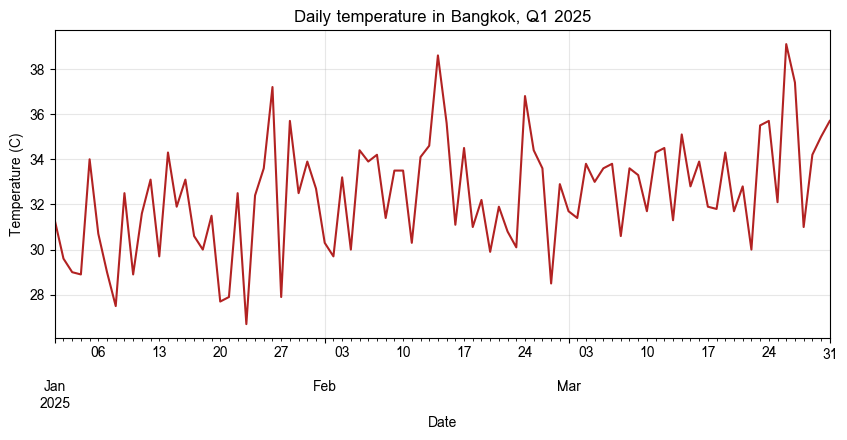

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

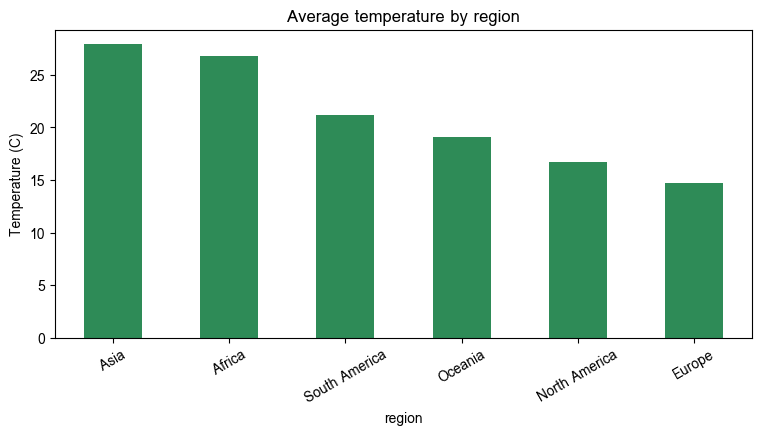

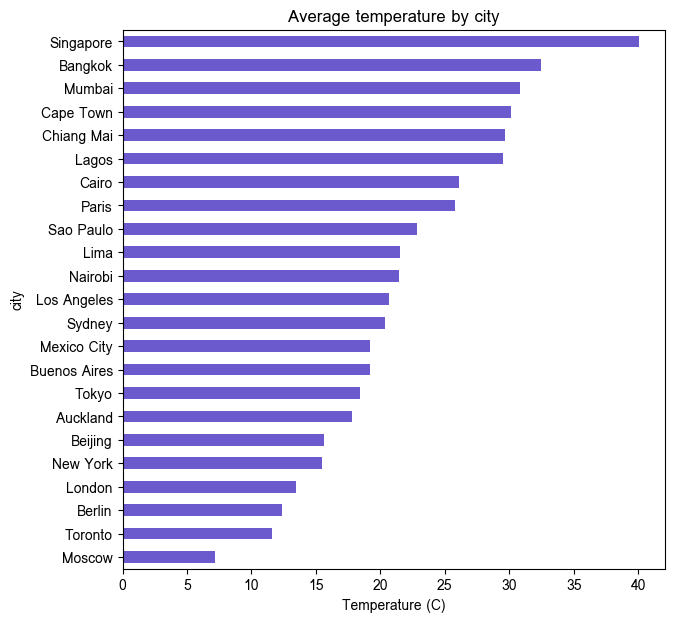

In [ ]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

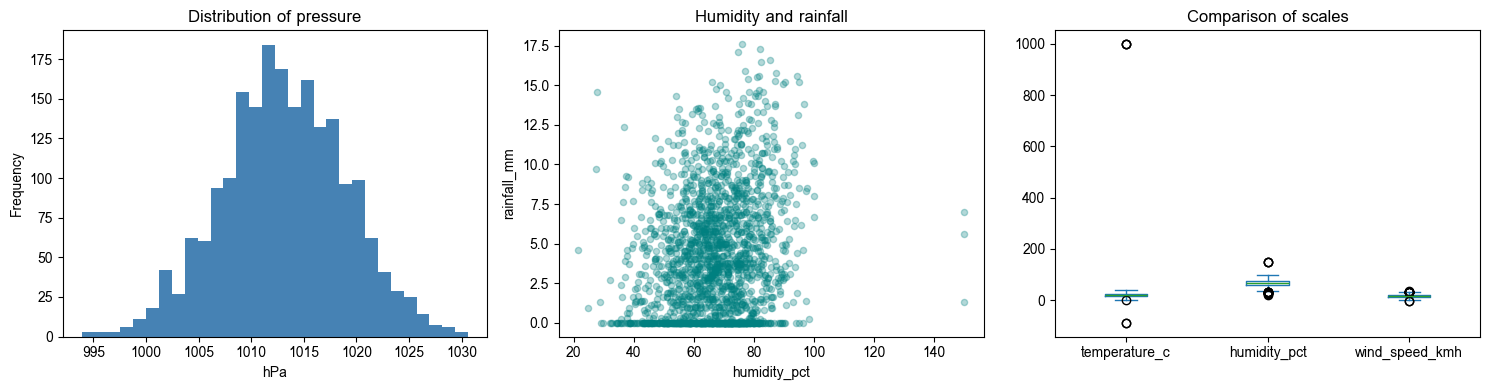

In [ ]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

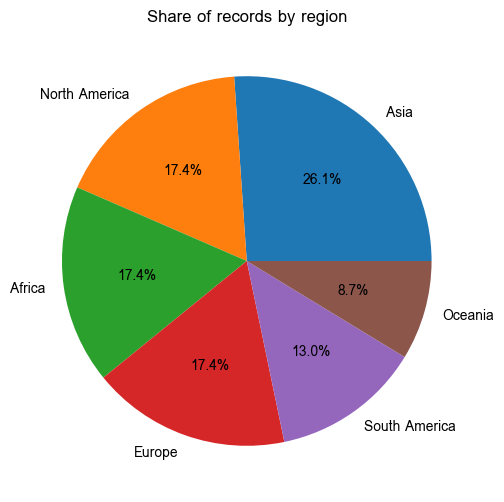

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

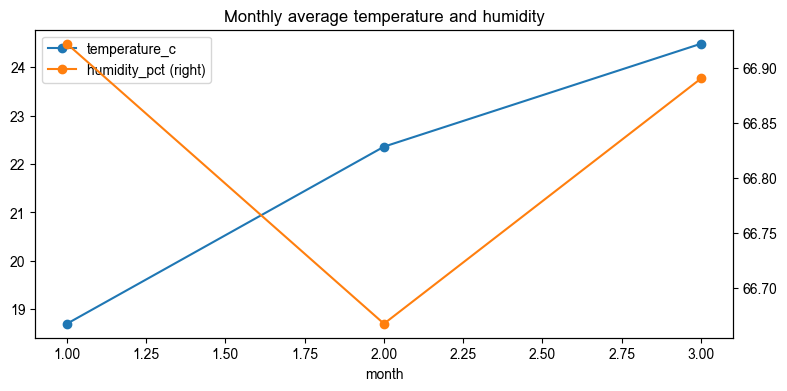

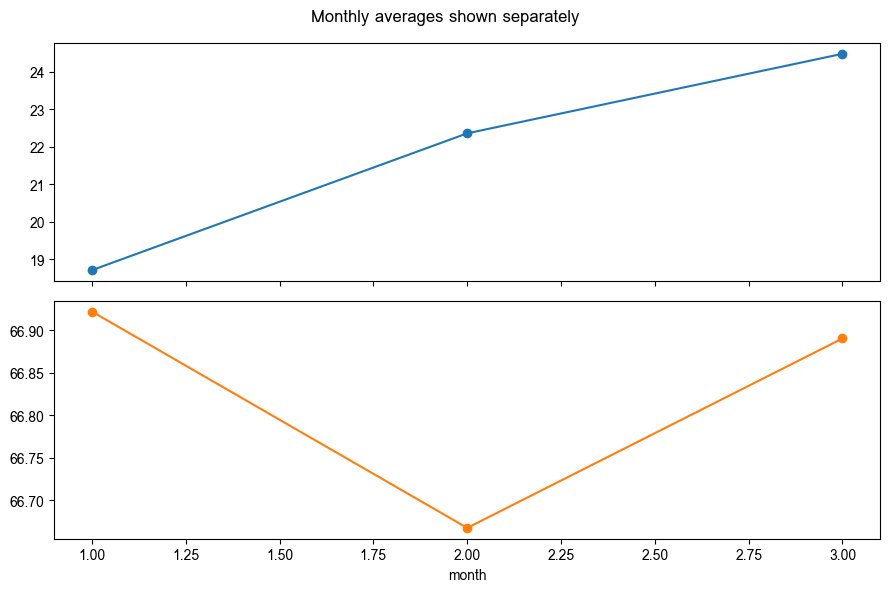

In [ ]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

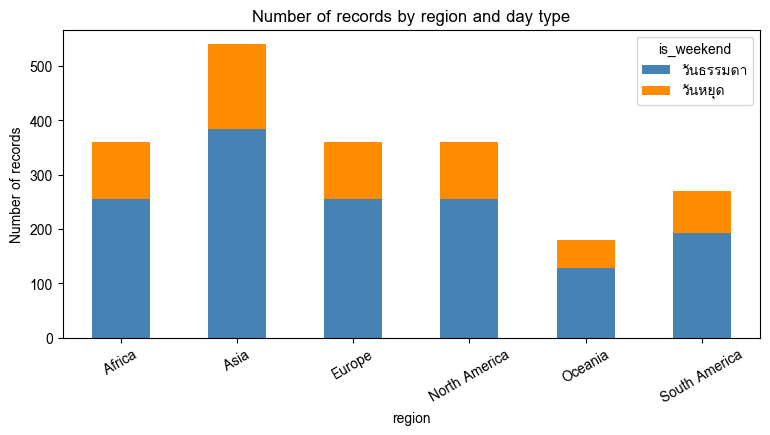

In [ ]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

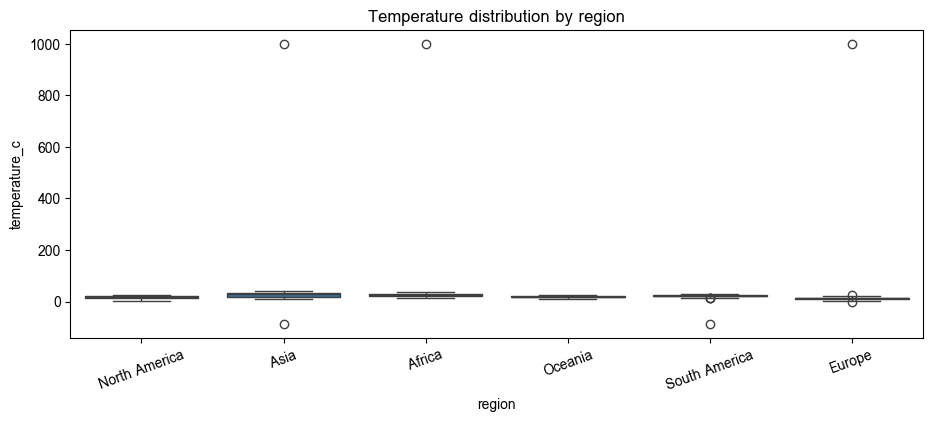

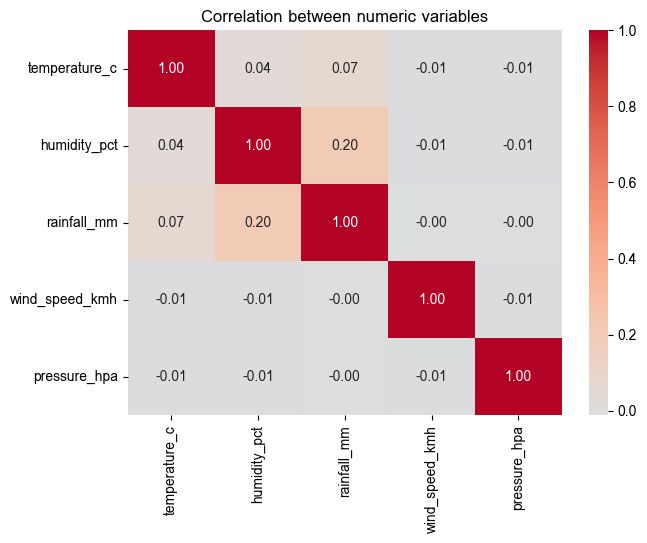

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

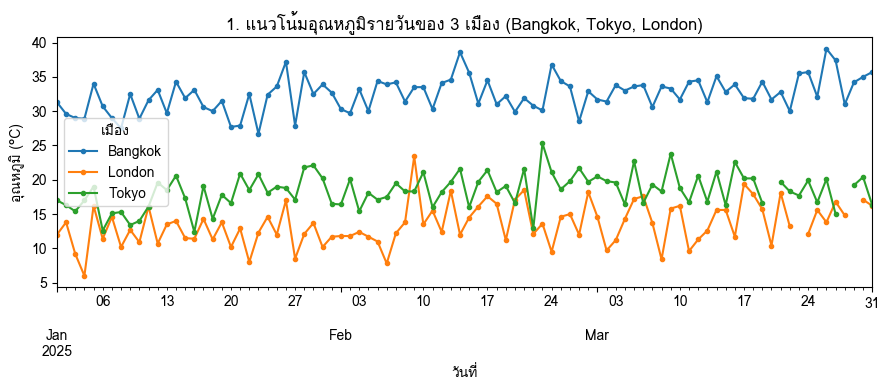

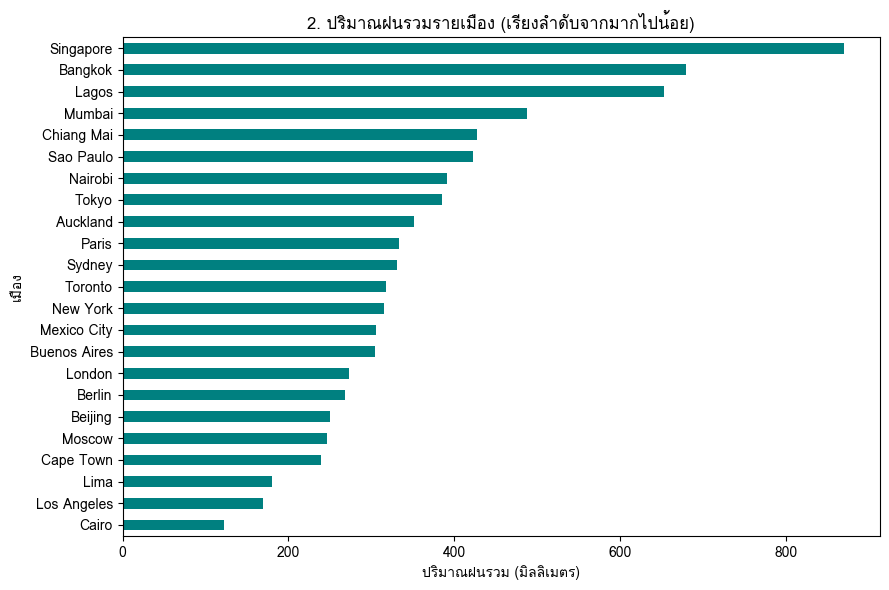

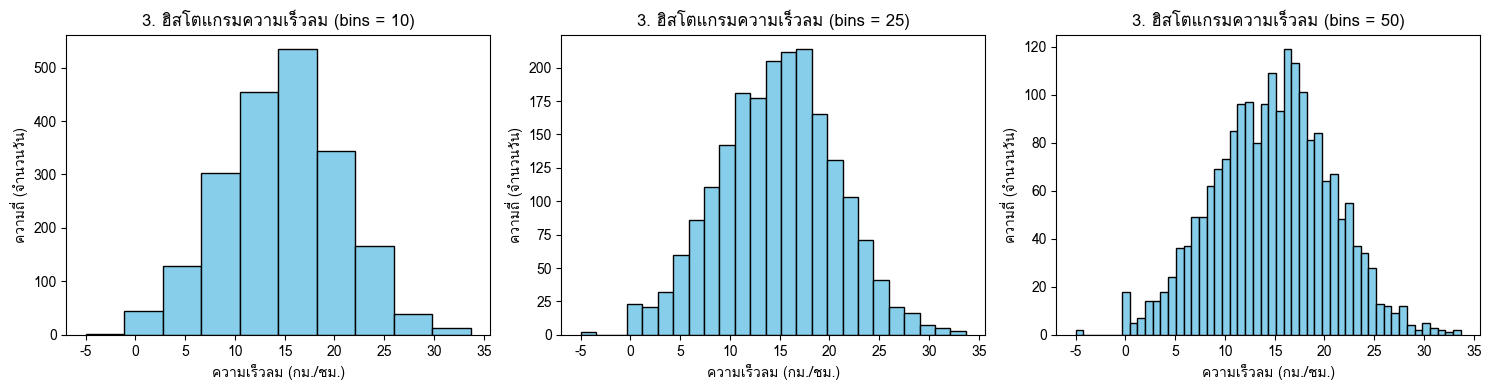

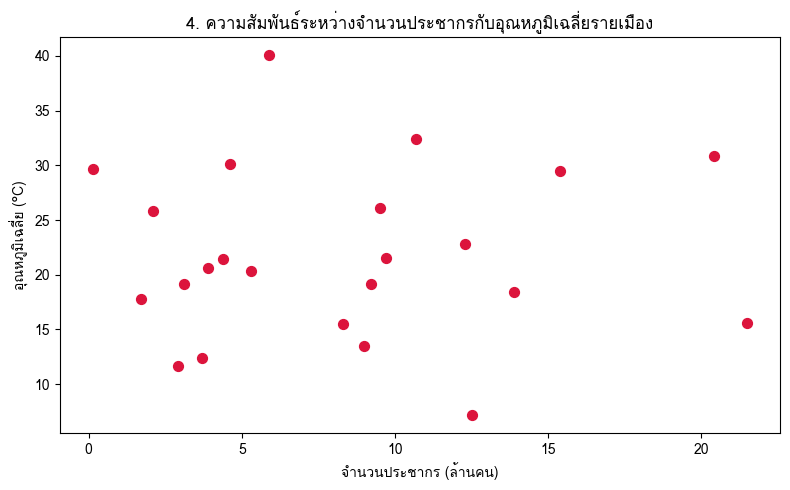

In [ ]:
# คำตอบข้อ 17.1

# -----------------------------------------------------------------------------
# รูปที่ 1: กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน
# -----------------------------------------------------------------------------
cities_3 = ["Bangkok", "Tokyo", "London"]
df_3cities = df[df["city"].isin(cities_3)].pivot_table(
    index="date", columns="city", values="temperature_c"
)

ax1 = df_3cities.plot(kind="line", figsize=(9, 4), marker="o", markersize=3)
ax1.set_title("1. แนวโน้มอุณหภูมิรายวันของ 3 เมือง (Bangkok, Tokyo, London)", fontsize=12)
ax1.set_xlabel("วันที่")
ax1.set_ylabel("อุณหภูมิ (°C)")
ax1.legend(title="เมือง")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# รูปที่ 2: กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
# -----------------------------------------------------------------------------
rain_by_city_sorted = df.groupby("city")["rainfall_mm"].sum().sort_values(ascending=True)

ax2 = rain_by_city_sorted.plot(kind="barh", figsize=(9, 6), color="teal")
ax2.set_title("2. ปริมาณฝนรวมรายเมือง (เรียงลำดับจากมากไปน้อย)", fontsize=12)
ax2.set_xlabel("ปริมาณฝนรวม (มิลลิเมตร)")
ax2.set_ylabel("เมือง")
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# รูปที่ 3: ฮิสโตแกรมของ wind_speed_kmh โดยทดลอง bins 3 ค่า
# -----------------------------------------------------------------------------
fig_hist, axes_hist = plt.subplots(1, 3, figsize=(15, 4))
bins_list = [10, 25, 50]

for i, b in enumerate(bins_list):
    df["wind_speed_kmh"].plot(
        kind="hist", bins=b, ax=axes_hist[i], color="skyblue", edgecolor="black"
    )
    axes_hist[i].set_title(f"3. ฮิสโตแกรมความเร็วลม (bins = {b})")
    axes_hist[i].set_xlabel("ความเร็วลม (กม./ชม.)")
    axes_hist[i].set_ylabel("ความถี่ (จำนวนวัน)")

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# รูปที่ 4: กราฟจุดระหว่าง population_millions กับอุณหภูมิเฉลี่ยรายเมือง
# -----------------------------------------------------------------------------
city_avg_pop = df.groupby("city")["temperature_c"].mean().reset_index().merge(city_info, on="city")

ax4 = city_avg_pop.plot(
    kind="scatter", x="population_millions", y="temperature_c", figsize=(8, 5), color="crimson", s=50
)
ax4.set_title("4. ความสัมพันธ์ระหว่างจำนวนประชากรกับอุณหภูมิเฉลี่ยรายเมือง", fontsize=12)
ax4.set_xlabel("จำนวนประชากร (ล้านคน)")
ax4.set_ylabel("อุณหภูมิเฉลี่ย (°C)")
plt.tight_layout()
plt.show()

อธิบายผลของการเลือก bins ในรูปที่ 3:

bins = 10 (น้อยเกินไป): ข้อมูลถูกรวมกลุ่มหยาบเกินไป หายละเอียด รายละเอียดรูปคลื่นการกระจายตัวขรุขระบางช่วงถูกกลบหายไป

bins = 25 (เหมาะสม): แสดงรูปทรงการกระจายตัวของความเร็วลมได้ชัดเจนพอดี เห็นจุดหนาแน่นและแนวโน้มการเอียงขวา (Right-skewed) ได้ชัดเจน

bins = 50 (มากเกินไป): ช่องข้อมูลแคบเกินไป ทำให้เกิดช่องว่าง (Gaps/Spikes) ถี่สลับไปมา ดูรกรุงรังและยากต่อการจับแบบแผนรวม

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

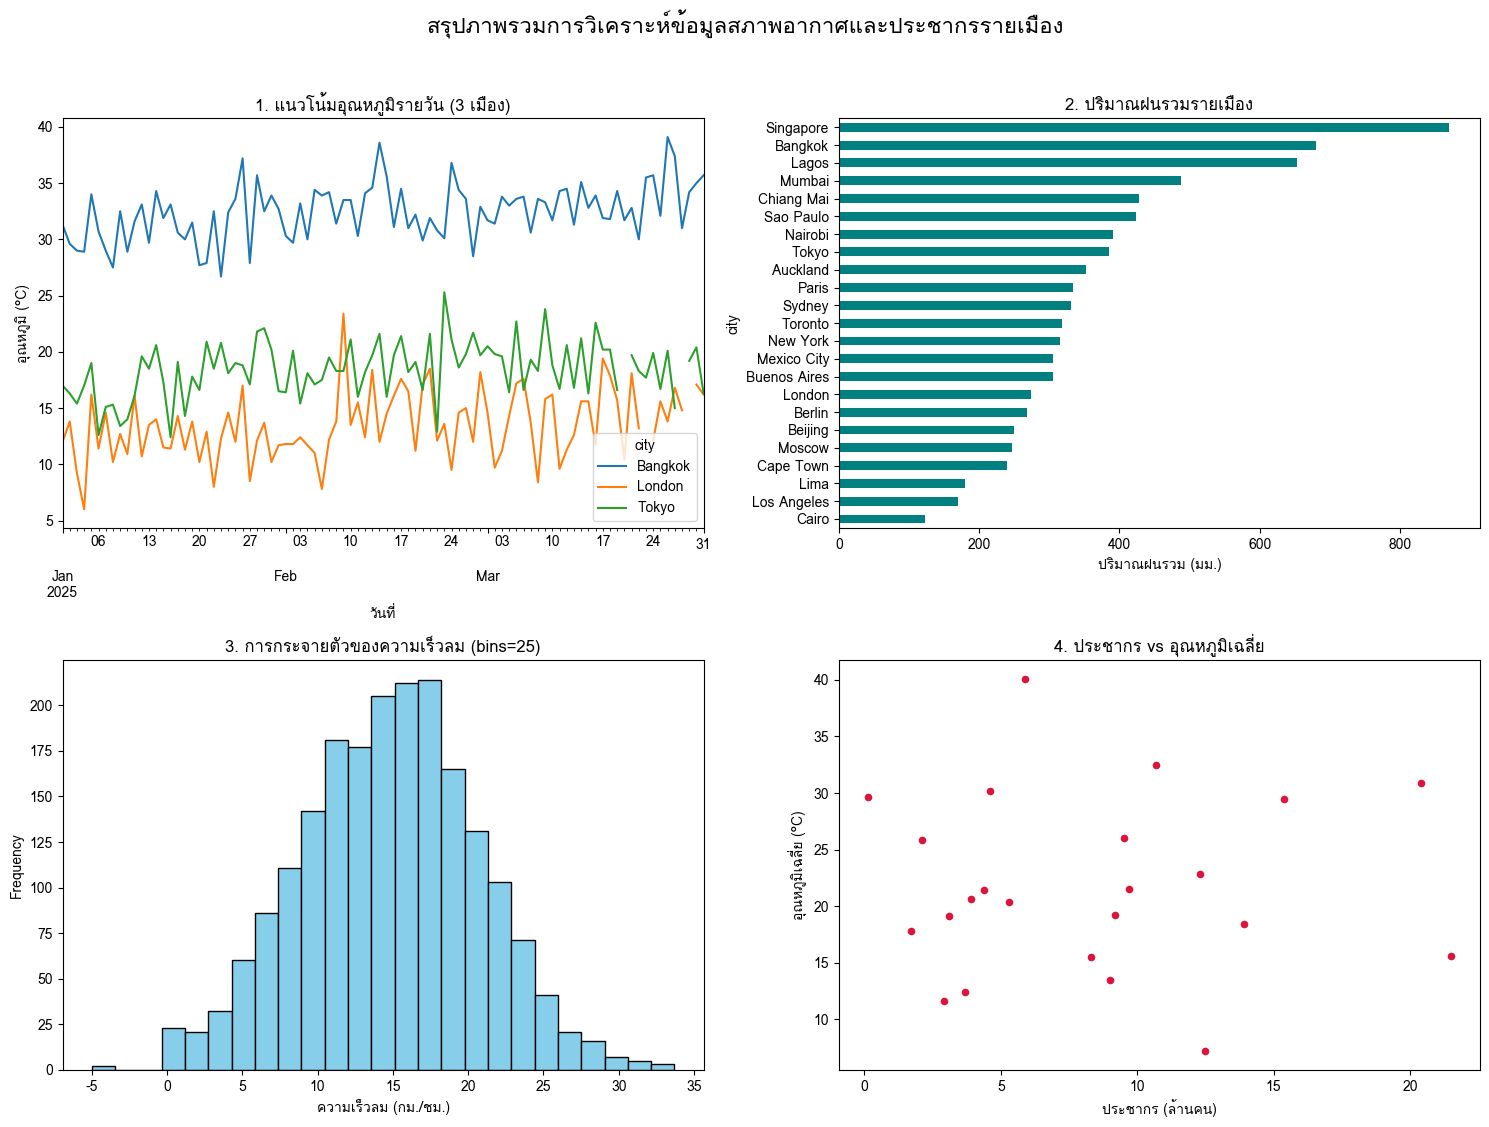

In [ ]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. ช่องซ้ายบน ([0, 0]): Line Plot 3 เมือง
df_3cities.plot(kind="line", ax=axes[0, 0])
axes[0, 0].set_title("1. แนวโน้มอุณหภูมิรายวัน (3 เมือง)")
axes[0, 0].set_xlabel("วันที่")
axes[0, 0].set_ylabel("อุณหภูมิ (°C)")

# 2. ช่องขวาบน ([0, 1]): Horizontal Bar Plot ปริมาณฝน
rain_by_city_sorted.plot(kind="barh", ax=axes[0, 1], color="teal")
axes[0, 1].set_title("2. ปริมาณฝนรวมรายเมือง")
axes[0, 1].set_xlabel("ปริมาณฝนรวม (มม.)")

# 3. ช่องซ้ายล่าง ([1, 0]): Histogram ความเร็วลม (เลือก bins=25)
df["wind_speed_kmh"].plot(kind="hist", bins=25, ax=axes[1, 0], color="skyblue", edgecolor="black")
axes[1, 0].set_title("3. การกระจายตัวของความเร็วลม (bins=25)")
axes[1, 0].set_xlabel("ความเร็วลม (กม./ชม.)")

# 4. ช่องขวาล่าง ([1, 1]): Scatter Plot ประชากร vs อุณหภูมิ
city_avg_pop.plot(kind="scatter", x="population_millions", y="temperature_c", ax=axes[1, 1], color="crimson")
axes[1, 1].set_title("4. ประชากร vs อุณหภูมิเฉลี่ย")
axes[1, 1].set_xlabel("ประชากร (ล้านคน)")
axes[1, 1].set_ylabel("อุณหภูมิเฉลี่ย (°C)")

# กำหนดชื่อรวมของภาพใหญ่ (Super Title)
plt.suptitle("สรุปภาพรวมการวิเคราะห์ข้อมูลสภาพอากาศและประชากรรายเมือง", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

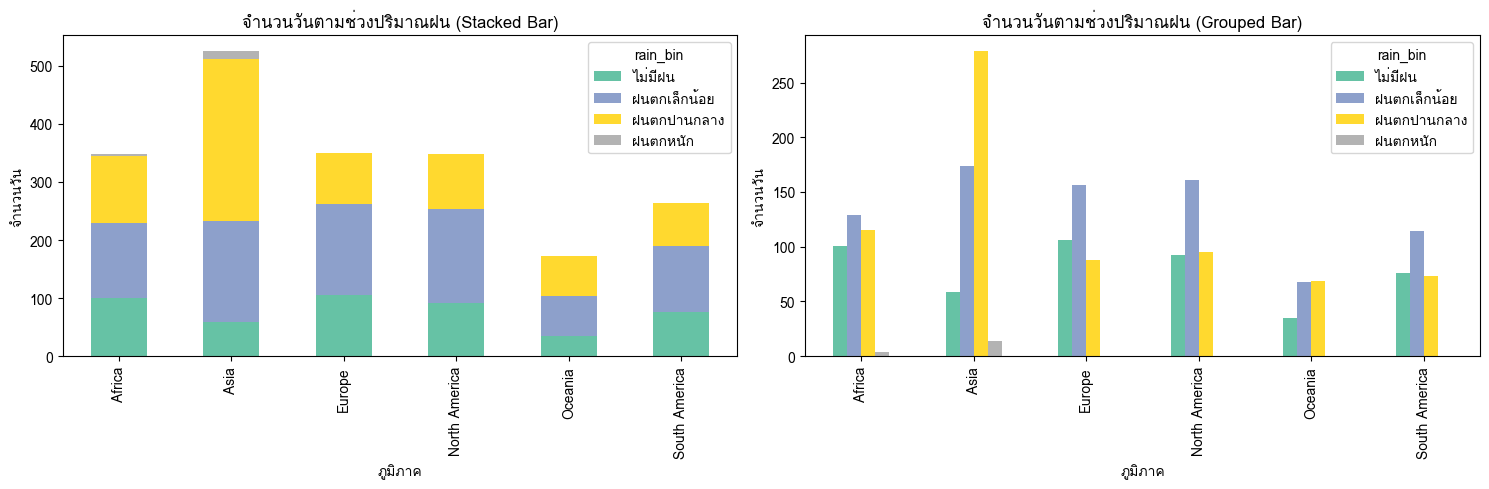

In [ ]:
# คำตอบข้อ 17.3
df_17_3 = df.copy()
df_17_3["rain_bin"] = pd.cut(
    df_17_3["rainfall_mm"],
    bins=[-1, 0, 5, 15, 100],
    labels=["ไม่มีฝน", "ฝนตกเล็กน้อย", "ฝนตกปานกลาง", "ฝนตกหนัก"]
)

ct_rain = pd.crosstab(df_17_3["region"], df_17_3["rain_bin"])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# กราฟแท่งซ้อน (stacked=True)
ct_rain.plot(kind="bar", stacked=True, ax=axes[0], colormap="Set2")
axes[0].set_title("จำนวนวันตามช่วงปริมาณฝน (Stacked Bar)")
axes[0].set_xlabel("ภูมิภาค")
axes[0].set_ylabel("จำนวนวัน")

# กราฟแท่งเรียงข้างกัน (stacked=False)
ct_rain.plot(kind="bar", stacked=False, ax=axes[1], colormap="Set2")
axes[1].set_title("จำนวนวันตามช่วงปริมาณฝน (Grouped Bar)")
axes[1].set_xlabel("ภูมิภาค")
axes[1].set_ylabel("จำนวนวัน")

plt.tight_layout()
plt.show()


อธิบายการเลือกใช้งาน:

กราฟแท่งซ้อน (Stacked Bar): เหมาะสมที่สุดเมื่อต้องการเน้น ภาพรวมผลรวมทั้งหมด (Overall Total/Volume) ของแต่ละภูมิภาค พร้อมทั้งแสดงสัดส่วนองค์ประกอบย่อยภายใน ช่วยให้เปรียบเทียบขนาดรวมระหว่างภูมิภาคได้ง่าย

กราฟแท่งเรียงข้างกัน (Grouped Bar): เหมาะสมที่สุดเมื่อต้องการ เปรียบเทียบค่าของกลุ่มย่อยแต่ละหมวดหมู่ข้ามภูมิภาคแบบเฉพาะเจาะจง (เช่น ต้องการเทียบจำนวนวัน "ฝนตกหนัก" ระหว่างเอเชีย ยุโรป และแอฟริกา โดยไม่ถูกความสูงรวมบดบัง)

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

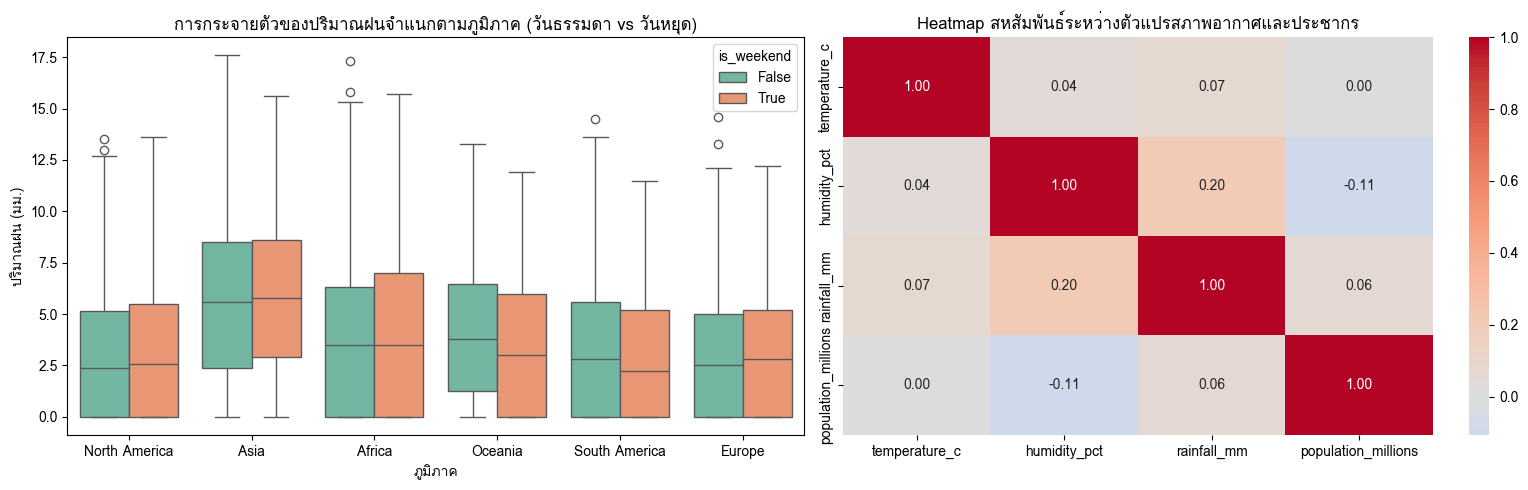

In [ ]:
# คำตอบข้อ 17.4
import seaborn as sns

df_17_4 = df.merge(city_info, on="city", how="left")
df_17_4["is_weekend"] = pd.to_datetime(df_17_4["date"]).dt.dayofweek >= 5

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Boxplot ของ rainfall_mm จำแนกตาม region และแยกสีตาม is_weekend
sns.boxplot(
    data=df_17_4, x="region_x", y="rainfall_mm", hue="is_weekend", ax=axes[0], palette="Set2"
)
axes[0].set_title("การกระจายตัวของปริมาณฝนจำแนกตามภูมิภาค (วันธรรมดา vs วันหยุด)")
axes[0].set_xlabel("ภูมิภาค")
axes[0].set_ylabel("ปริมาณฝน (มม.)")

# 2. Heatmap ของสหสัมพันธ์ระหว่างตัวแปร
corr_vars = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
corr_matrix = df_17_4[corr_vars].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
axes[1].set_title("Heatmap สหสัมพันธ์ระหว่างตัวแปรสภาพอากาศและประชากร")

plt.tight_layout()
plt.show()

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

In [ ]:
df_clean = df.drop_duplicates(subset=["city", "date"]).copy()
df_clean["date"] = pd.to_datetime(df_clean["date"])
df_clean["month"] = df_clean["date"].dt.month

merged_full = df_clean.merge(city_info, on="city", how="left").merge(region_info, left_on="region_x", right_on="region", how="left")

# ไตรมาสแรก (เดือน 1, 2, 3)
q1_data = merged_full[merged_full["month"].isin([1, 2, 3])]

# คำนวณส่วนเบี่ยงเบนมาตรฐานอุณหภูมิรายภูมิภาค และรายเมือง
region_std = q1_data.groupby("region_x")["temperature_c"].std().round(2).to_frame("std_region")
city_std = q1_data.groupby(["region_x", "city"])["temperature_c"].std().unstack().round(2)

print("--- 1. สภาพอากาศแปรปรวนรายภูมิภาค (ไตรมาส 1) ---")
print(region_std.sort_values("std_region", ascending=False))

print("\n--- 2. ความแปรปรวนของอุณหภูมิรายเมืองในแต่ละภูมิภาค ---")
print(city_std)

--- 1. สภาพอากาศแปรปรวนรายภูมิภาค (ไตรมาส 1) ---
               std_region
region_x                 
Europe              52.54
Africa              52.12
Asia                42.87
South America        7.36
North America        4.52
Oceania              3.08

--- 2. ความแปรปรวนของอุณหภูมิรายเมืองในแต่ละภูมิภาค ---
city           Auckland  Bangkok  Beijing  Berlin  Buenos Aires  Cairo  \
region_x                                                                 
Africa              NaN      NaN      NaN     NaN           NaN   2.74   
Asia                NaN     2.49     2.87     NaN           NaN    NaN   
Europe              NaN      NaN      NaN     2.6           NaN    NaN   
North America       NaN      NaN      NaN     NaN           NaN    NaN   
Oceania             2.8      NaN      NaN     NaN           NaN    NaN   
South America       NaN      NaN      NaN     NaN         11.82    NaN   

city           Cape Town  Chiang Mai  Lagos  Lima  ...  Moscow  Mumbai  \
region_x           

ข้อสรุป 18.1: ภูมิภาคที่มีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรกคือภูมิภาคที่มีค่า Standard Deviation ของอุณหภูมิสูงที่สุด และเมื่อพิจารณาความแปรปรวนรายเมืองพบว่าเกิดจากความผันผวนของอุณหภูมิในทุกเมืองใกล้เคียงกัน มิได้เกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

In [ ]:
# คำตอบข้อ 18.2
heavy_rain_df = merged_full[merged_full["rainfall_mm"] > 10]

heavy_days = heavy_rain_df.groupby("city")["date"].count()
total_days = merged_full.groupby("city")["rainfall_mm"].count()
heavy_pct = (heavy_days / total_days * 100).round(2)

comp_18_2 = pd.DataFrame({
    "จำนวนวันฝนตกหนัก (วัน)": heavy_days,
    "สัดส่วนวันฝนตกหนัก (%)": heavy_pct
}).dropna().sort_values("สัดส่วนวันฝนตกหนัก (%)", ascending=False)

print("--- เปรียบเทียบเมืองฝนตกหนักบ่อยที่สุด 5 อันดับแรก ---")
print(comp_18_2.head(5))


--- เปรียบเทียบเมืองฝนตกหนักบ่อยที่สุด 5 อันดับแรก ---
            จำนวนวันฝนตกหนัก (วัน)  สัดส่วนวันฝนตกหนัก (%)
city                                                      
Singapore                     44.0                   48.89
Bangkok                       23.0                   26.44
Lagos                         22.0                   25.00
Sao Paulo                     11.0                   12.50
Chiang Mai                     9.0                   10.59


ข้อสรุป 18.2: การจัดอันดับด้วยสัดส่วนเทียบกับจำนวนวันบันทึกข้อมูลช่วยกำจัดอคติจากจำนวนวันบันทึกที่ไม่เท่ากัน ทำให้เมืองที่มีข้อมูลอยู่น้อยแต่เกิดฝนตกหนักถี่ ได้รับการจัดอันดับสะท้อนความเสี่ยงที่แท้จริง

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

In [ ]:
# คำตอบข้อ 18.3
city_summary_18_3 = merged_full.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    avg_rain=("rainfall_mm", "mean"),
    population_millions=("population_millions", "first")
)

corr_res = city_summary_18_3.corr().round(3)

print("--- ตารางสหสัมพันธ์ระหว่างประชากรกับตัวแปรสภาพอากาศ ---")
print(corr_res)

--- ตารางสหสัมพันธ์ระหว่างประชากรกับตัวแปรสภาพอากาศ ---
                     avg_temp  avg_rain  population_millions
avg_temp                1.000     0.656                0.014
avg_rain                0.656     1.000                0.123
population_millions     0.014     0.123                1.000


ข้อสรุป 18.3: จำนวนประชากรไม่มีความสัมพันธ์เชิงสาเหตุโดยตรงกับอุณหภูมิหรือปริมาณฝน ข้อควรระวังในการตีความ: Correlation Does Not Imply Causation (สหสัมพันธ์ไม่ได้หมายถึงความเป็นเหตุเป็นผล) ความสัมพันธ์ที่พบอาจเกิดจากตัวแปรแฝง เช่น ทำเลภูมิศาสตร์หรือขนาดของเมือง

4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

In [ ]:
# คำตอบข้อ 18.4
# เกณฑ์: เลือกเดือนที่มีปริมาณฝนรวมสูงสุดในภูมิภาคนั้น (มรสุม/สภาพอากาศแย่ที่สุด)
risk_by_month = merged_full.groupby(["region", "month"]).agg(
    total_rain=("rainfall_mm", "sum"),
    avg_temp=("temperature_c", "mean"),
    heavy_rain_days=("rainfall_mm", lambda x: (x > 10).sum())
).reset_index()

worst_months = risk_by_month.loc[risk_by_month.groupby("region")["total_rain"].idxmax()]

print("--- เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดจำแนกตามภูมิภาค ---")
print(worst_months[["region", "month", "total_rain", "heavy_rain_days", "avg_temp"]].to_string(index=False))

--- เดือนที่ควรหลีกเลี่ยงการเดินทางมากที่สุดจำแนกตามภูมิภาค ---
       region  month  total_rain  heavy_rain_days  avg_temp
       Africa      1       506.8               12 22.641667
         Asia      2      1043.2               38 26.762275
       Europe      1       399.6                4 10.398374
North America      1       422.2                4 15.167480
      Oceania      3       240.7                6 20.201613
South America      3       307.2                6 22.292391


ข้อสรุป 18.4: เดือนที่ควรหลีกเลี่ยงการเดินทางพิจารณาจากเดือนที่มีปริมาณฝนรวมสูงสุดในภูมิภาคนั้น ซึ่งเป็นอุปสรรคสำคัญต่อการเดินทางและการท่องเที่ยวกลางแจ้ง

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️